# Inchcape / Suzuki Collision Parts Forecasting EP — Notebook 1: Understanding the Data

This notebook is the first teaching notebook for the employer project.

The objective is not to build a forecasting model yet. Instead, the objective is to understand the data, the forecasting problem, and the characteristics of spare-parts demand before selecting forecasting techniques.

By the end of this notebook you should be able to explain:

1. What one row in the dataset represents.
2. What the forecasting target is.
3. How many SKUs (Stock Keeping Units) and months of history are available.
4. Whether demand is concentrated in a small number of SKUs.
5. Whether demand exhibits intermittent behaviour.
6. The difference between smooth, intermittent, erratic and lumpy demand.
7. Why understanding demand patterns is important when selecting forecasting methods.

The insights from this notebook will be used to justify and evaluate the forecasting approaches explored in the modelling notebooks that follow.

## 0. Problem  we are trying to solve:

> Inchcape needs to decide how many spare parts to keep in stock. If the forecast is too low, repair jobs can be delayed. If the forecast is too high, cash is tied up in slow-moving stock.

In this dataset:

- `ts_id` is the SKU / spare part identifier.
- `Date` is the month.
- `value` is the monthly demand quantity. This is what we will forecast later.
- `collision_flag` tells us whether the part is collision-related.
- Other columns may be useful explanatory features, such as stock levels, price, product family, and macroeconomic variables.

## 1. Install and import packages



In [34]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 5)

## 3. Load the data

The full dataset may be large. If you receive it as a CSV, it will usually load faster than Excel. If it is still Excel, this code will still work, but may take longer.

In [35]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [36]:
# Define the correct paths for files within this cell to override previous definitions if needed
data_path = "gdrive/My Drive/Colab Notebooks/chile_suzuki_historical_sales.csv"
dictionary_path = "gdrive/My Drive/Colab Notebooks/forecasting_data_dictionary.xlsx"

# Load files with the correct Pandas functions
sales_df = pd.read_csv(data_path)
dictionary_df = pd.read_excel(dictionary_path)
external_data = pd.read_csv("gdrive/My Drive/Colab Notebooks/monthly_external_features.csv")

In [37]:
# Inspect
print("Sales data shape: ",sales_df.shape)
print()
print(sales_df.info())
print(sales_df.head())
print('----------------')
print("Data dictionary shape: ",dictionary_df.shape)
print()
print(dictionary_df.head())

Sales data shape:  (952504, 51)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952504 entries, 0 to 952503
Data columns (total 51 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ts_id                           952504 non-null  object 
 1   COUNTRY_BRAND_CHANNEL           952504 non-null  object 
 2   Country                         952504 non-null  object 
 3   Brand                           952504 non-null  object 
 4   Channel                         952504 non-null  object 
 5   Date                            952504 non-null  object 
 6   REVENUE                         244996 non-null  float64
 7   COST                            244996 non-null  float64
 8   UNIT_PRICE                      244996 non-null  float64
 9   TOTAL_PROFIT                    244996 non-null  float64
 10  UNIT_COST                       244996 non-null  float64
 11  STOCK_END_MONTH                 271377 non-nu

In [38]:
print(sales_df.head())

            ts_id   COUNTRY_BRAND_CHANNEL Country   Brand       Channel  \
0   015500620A000  CHILE_SUZUKI_WHOLESALE   CHILE  SUZUKI  DISTRIBUTION   
1   015501020A000  CHILE_SUZUKI_WHOLESALE   CHILE  SUZUKI  DISTRIBUTION   
2   015501035C000  CHILE_SUZUKI_WHOLESALE   CHILE  SUZUKI  DISTRIBUTION   
3     01550M0612A  CHILE_SUZUKI_WHOLESALE   CHILE  SUZUKI  DISTRIBUTION   
4  01550M0825A000  CHILE_SUZUKI_WHOLESALE   CHILE  SUZUKI  DISTRIBUTION   

         Date  REVENUE  COST  UNIT_PRICE  TOTAL_PROFIT  UNIT_COST  \
0  2022-07-01      NaN   NaN         NaN           NaN        NaN   
1  2024-01-01      NaN   NaN         NaN           NaN        NaN   
2  2023-08-01      NaN   NaN         NaN           NaN        NaN   
3  2022-04-01      NaN   NaN         NaN           NaN        NaN   
4  2025-02-01      NaN   NaN         NaN           NaN        NaN   

   STOCK_END_MONTH  STOCK_START_MONTH  NEW_ENTRY_STOCK  Bank_Lending_Rate  \
0              NaN                NaN              NaN   

## 4. Read the data dictionary

This is a good teaching habit: before analysing the numbers, check what each column is supposed to mean.

In [39]:
# Show the full dictionary if it is not too large.
display(dictionary_df)

# Create a quick lookup table for later.
if "column_name" in dictionary_df.columns and "description" in dictionary_df.columns:
    dictionary_lookup = dict(zip(dictionary_df["column_name"], dictionary_df["description"]))
else:
    dictionary_lookup = {}

,column_name,description,business_category
0,ts_id,Unique identifier of a SKU or vehicle part.,Identifier
1,COUNTRY_BRAND_CHANNEL,"Combination of country, brand and sales channel.",General
2,Country,Country associated with the sales record.,General
3,Brand,Vehicle brand associated with the part.,General
4,Channel,Sales distribution channel.,General
5,Date,Month and year of the sales observation.,Datetime
6,REVENUE,Total revenue generated by the SKU during the ...,Financial
7,COST,Total cost associated with the SKU sales durin...,Financial
8,UNIT_PRICE,Average selling price per unit for the SKU.,Financial
9,TOTAL_PROFIT,Total profit generated during the month.,Financial


## 5. Standardise key column names

We will keep the original columns, but create a few standard names to make the rest of the notebook easier to read:

- `sku_id` = SKU identifier
- `date` = monthly date
- `demand` = quantity to forecast
- `is_collision` = collision-parts flag

In this step, we keep the original data unchanged and create a cleaner working dataframe called `sales`.
We rename the key fields into forecasting language:
- `ts_id` becomes `sku_id`
- `Date` becomes `month`
- `value` becomes `demand`
- `collision_flag` becomes `is_collision`

We take the messy/raw business file and create clear forecasting columns: SKU, month, demand, and collision flag.

In [40]:
# make a copy of the original data.
sales = sales_df.copy()

# check that the essential columns exist before  continuing.
required_columns = ["ts_id", "Date", "value", "collision_flag"]
missing_required = [c for c in required_columns if c not in sales.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

sales["sku_id"] = sales["ts_id"].astype(str)  # a clearer column name
sales["date"] = pd.to_datetime(sales["Date"]) # convert Date into a proper pandas date column.

# create the target variable
# errors="coerce" means: if there is anything weird that cannot be converted to a number, turn it into missing.
#.fillna(0) means: treat missing demand as zero
#need to check whether missing value really means zero demand, or whether it means missing data.
sales["demand"] = pd.to_numeric(sales["value"], errors="coerce").fillna(0)

# clean the collision flag making all occurances of collision consistent 'COLLISION'.
sales["collision_flag_clean"] = sales["collision_flag"].astype(str).str.strip().str.upper()

#creates a true/false column:is_collision = True or False
#Because our data has:NON COLLISION and that also contains the word COLLISION.
sales["is_collision"] = sales["collision_flag_clean"].str.contains("COLLISION") & ~sales["collision_flag_clean"].str.contains("NON")

# Force all dates to month start, in case dates arrive with different days. data already seems monthly, but this makes it safe
sales["month"] = sales["date"].dt.to_period("M").dt.to_timestamp()

print("Date range:", sales["month"].min(), "to", sales["month"].max())
print("Number of rows:", len(sales))
print("Number of SKUs:", sales["sku_id"].nunique())
print("Collision flag values:")
print(sales["collision_flag"].value_counts(dropna=False))

display(sales[["sku_id", "month", "demand", "collision_flag", "is_collision"]].head())

Date range: 2021-01-01 00:00:00 to 2026-04-01 00:00:00
Number of rows: 952504
Number of SKUs: 19143
Collision flag values:
collision_flag
NON COLLISION    772082
COLLISION        180422
Name: count, dtype: int64


,sku_id,month,demand,collision_flag,is_collision
0,015500620A000,2022-07-01,0.0,NON COLLISION,False
1,015501020A000,2024-01-01,0.0,NON COLLISION,False
2,015501035C000,2023-08-01,0.0,NON COLLISION,False
3,01550M0612A,2022-04-01,0.0,NON COLLISION,False
4,01550M0825A000,2025-02-01,0.0,NON COLLISION,False


## 6. Understand the collision parts scope

The project focuses on forecasting demand for collision spare parts. Before building any forecasting models, we need to understand how collision and non-collision parts are represented in the data.

In this section we will:

- Examine the values in `collision_flag`
- Understand how many SKUs are classified as collision parts
- Compare the volume of collision and non-collision records
- Confirm that the data contains the expected project scope

At this stage, we are only exploring the data. We will decide later whether to filter the dataset to collision parts only for modelling and evaluation.


In [41]:
print("All rows:", len(sales))
print("Collision rows:", sales["is_collision"].sum())
print("All SKUs:", sales["sku_id"].nunique())
print("Collision SKUs:", sales.loc[sales["is_collision"], "sku_id"].nunique())

# Get only the rows where is_collision == True
sales.loc[sales["is_collision"], ["sku_id", "month", "demand", "collision_flag"]].head()

All rows: 952504
Collision rows: 180422
All SKUs: 19143
Collision SKUs: 8097


,sku_id,month,demand,collision_flag
9,083144012A000,2024-08-01,0.0,COLLISION
16,09148M06022000,2025-01-01,0.0,COLLISION
31,0926225187000,2025-10-01,0.0,COLLISION
38,0928044008000,2024-06-01,0.0,COLLISION
39,0928044008000,2024-12-01,0.0,COLLISION


## 7. Basic data quality checks

Before modelling, we should check:

- Are there duplicate SKU-month rows?
- Are dates monthly?
- Are there missing target values?
- Are there negative demand values?
- Are there missing product descriptions?

In [42]:
print("Rows:", len(sales))
print("Unique SKUs:", sales["sku_id"].nunique())
print("Date range:", sales["month"].min(), "to", sales["month"].max())
print("Missing demand:", sales["demand"].isna().sum())
print("Negative demand:", (sales["demand"] < 0).sum())
print("Duplicate SKU-months:", sales.duplicated(["sku_id", "month"]).sum())

Rows: 952504
Unique SKUs: 19143
Date range: 2021-01-01 00:00:00 to 2026-04-01 00:00:00
Missing demand: 0
Negative demand: 0
Duplicate SKU-months: 0


The data is already remarkably clean



## 8. Check how much monthly history each SKU has

Before modelling, we need to understand how much history is available for each SKU.

This section does not yet check the exact location of missing months. It simply counts how many monthly observations each SKU has.

This helps us understand whether most SKUs have a long enough history for forecasting, and whether some SKUs may be new, discontinued, or only active for a short period.

In [43]:
months_per_sku = sales.groupby("sku_id")["month"].nunique()

print("Minimum months per SKU:", months_per_sku.min())
print("Median months per SKU:", months_per_sku.median())
print("Maximum months per SKU:", months_per_sku.max())

months_per_sku.describe()

Minimum months per SKU: 1
Median months per SKU: 58.0
Maximum months per SKU: 64


,month
count,19143.000000
mean,49.757300
std,17.650664
min,1.000000
25%,41.000000
50%,58.000000
75%,63.000000
max,64.000000


### Interpretation

The dataset contains 19,143 unique SKUs.

Most SKUs have a long history available, with a median of 58 monthly observations and many SKUs having nearly the full 64 months of data.

However, there is also a substantial group of SKUs with much shorter histories. The average history length is only 49.8 months, indicating that some SKUs have limited historical data available.

This is important because forecasting performance often depends on the amount of history available. Models may perform differently for mature SKUs with long histories compared with newer or less frequently observed SKUs.

### Why does this matter for forecasting?

Because

Different SKUs present different forecasting challenges.

* SKU with 64 months: Jan 2021 → Apr 2026

 Advantages:

enough history for seasonality

enough history for trends

enough history for deep learning models

enough history for foundation models

* SKU with 12 months

Advantages:

recent information

Challenges:

almost no seasonality information

little trend information

harder to forecast reliably

* SKU with 1 month

Practically impossible to forecast from its own history.

This is where:

global models

foundation models

cross-SKU learning

become important.

How many SKUs have less than 1 year of history?

How many SKUs have less than 2 year of history?

How many SKUs have less than 4 year of history?

In [44]:
print("SKUs with less than 12 months:", (months_per_sku < 12).sum())
print("SKUs with less than 24 months:", (months_per_sku < 24).sum())
print("SKUs with at least 48 months:", (months_per_sku >= 48).sum())

SKUs with less than 12 months: 1134
SKUs with less than 24 months: 2465
SKUs with at least 48 months: 13244


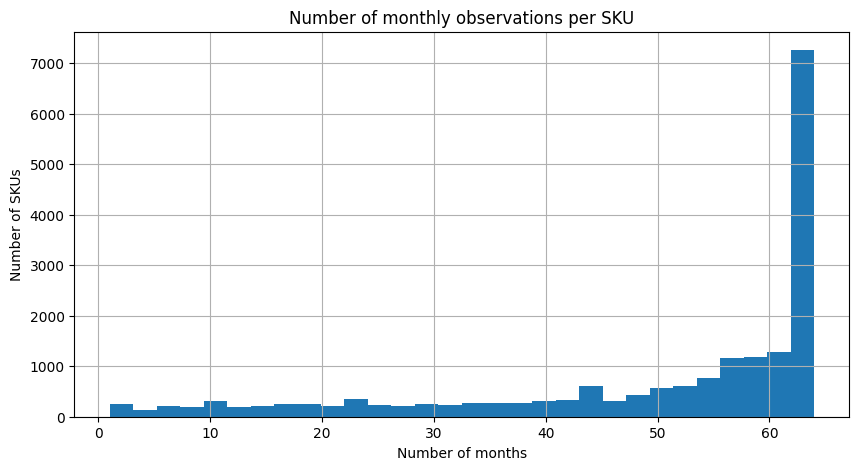

In [45]:
months_per_sku.hist(bins=30)
plt.title("Number of monthly observations per SKU")
plt.xlabel("Number of months")
plt.ylabel("Number of SKUs")
plt.show()

Our dataset spans:

Jan 2021 → Apr 2026

which is about 64 months.

The huge spike around 63–64 months means:

A large number of SKUs appear throughout almost the entire history of the dataset.

That's actually a good sign.

The long tail stretching back towards 1–20 months means:

Many SKUs have much shorter histories.

Possible reasons:

New parts introduced recently

Discontinued parts

Parts that rarely sell

Data collection starting later for some SKUs

## 9. Overall demand over time

This shows whether total demand is stable, seasonal, growing, declining, or affected by unusual months.

In [46]:
monthly_total = (
    sales
    .groupby("month", as_index=False)
    .agg(
        total_demand=("demand", "sum"),
        active_skus=("demand", lambda x: (x > 0).sum())
    )
)

display(monthly_total.head())

,month,total_demand,active_skus
0,2021-01-01,43557.0,4507
1,2021-02-01,40944.0,4429
2,2021-03-01,41526.0,4622
3,2021-04-01,33555.0,4276
4,2021-05-01,35554.0,4174


In [47]:
monthly_total.describe()

,month,total_demand,active_skus
count,64,64.000000,64.000000
mean,2023-08-16 18:00:00,34525.421875,4126.328125
min,2021-01-01 00:00:00,17663.000000,2922.000000
25%,2022-04-23 12:00:00,27220.500000,3725.750000
50%,2023-08-16 12:00:00,31632.000000,4034.500000
75%,2024-12-08 18:00:00,42805.250000,4517.500000
max,2026-04-01 00:00:00,52955.000000,5082.000000
std,NaN,9119.300182,505.316970


* total demand ranges from ~17,663 to ~52,955
* active SKUs range from ~2,922 to ~5,082
* there are 64 monthly observations

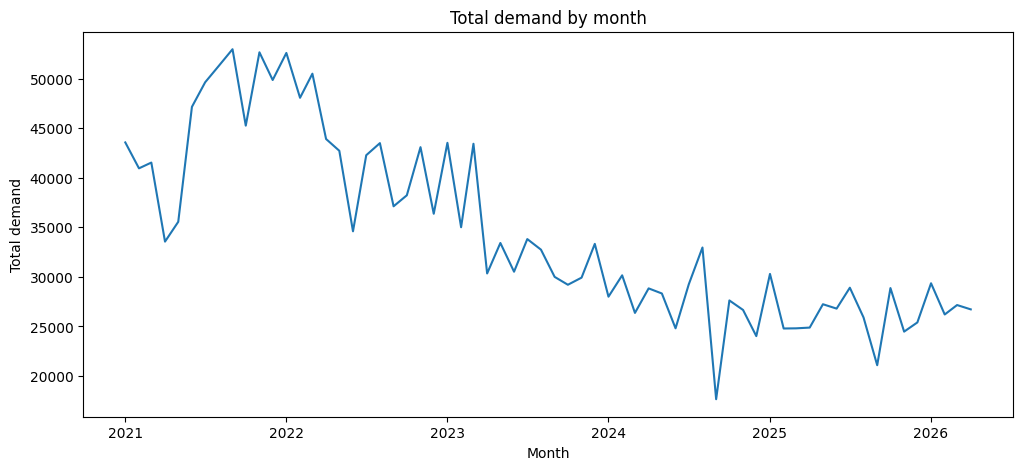

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_total["month"],
    monthly_total["total_demand"]
)

plt.title("Total demand by month")
plt.xlabel("Month")
plt.ylabel("Total demand")

plt.show()


* Is demand growing?
* Is demand falling?
* Is there seasonality?
* Are there unusual spikes?

* Higher in 2021–2022
* Declining through 2023
* Lower level in 2024–2026

## 10. Understand demand concentration and intermittent demand

Before building forecasting models, we need to understand how demand behaves at SKU level.

This section answers two important questions:

1. Is demand concentrated in a small number of SKUs? `total_demand` sorted
2. How often does each SKU have months with zero demand? through `zero_month_share`

This matters because the project will be evaluated using WMAPE. WMAPE gives more weight to high-demand SKUs, so a model can look good overall even if it performs badly for many low-demand SKUs.

The zero-demand share also helps us understand whether the data has intermittent demand, which is common in spare-parts forecasting.

`zero_month_share = number of observed months with zero demand / total observed months for that SKU`



In [49]:
sku_summary = (
    sales
    .groupby("sku_id") # for each SKU, summarise all its monthly rows
    .agg(
        total_demand=("demand", "sum"), # Total quantity sold for that SKU across all observed months.
        mean_monthly_demand=("demand", "mean"), # Average monthly demand for that SKU, based only on months present in the data.
        max_monthly_demand=("demand", "max"), #The biggest monthly demand value for that SKU.
        months_with_demand=("demand", lambda x: (x > 0).sum()), # Counts how many months had demand above zero.
        total_months=("month", "nunique") # Counts how many months that SKU appears in the dataset.
    )
    .reset_index()
)

sku_summary["zero_demand_months"] = (
    sku_summary["total_months"] - sku_summary["months_with_demand"]
)

sku_summary["zero_month_share"] = (
    sku_summary["zero_demand_months"] / sku_summary["total_months"]
)

sku_summary = sku_summary.sort_values("total_demand", ascending=False)

display(sku_summary.head(4))

print("Total SKUs:", len(sku_summary))
print("SKUs with zero total demand:", (sku_summary["total_demand"] == 0).sum())
print("Median zero-month share:", round(sku_summary["zero_month_share"].median(), 3))

,sku_id,total_demand,mean_monthly_demand,max_monthly_demand,months_with_demand,total_months,zero_demand_months,zero_month_share
158,09168M14015000,206463.0,3225.984375,5871.0,64,64,0,0.0
2410,16510M68K20000,137729.0,2152.015625,3157.0,64,64,0,0.0
2398,1651061A33000,72156.0,1127.437500,2722.0,64,64,0,0.0
490,09482M00636000,67785.0,1059.140625,2033.0,64,64,0,0.0


Total SKUs: 19143
SKUs with zero total demand: 52
Median zero-month share: 0.875


Median zero-month share = 0.875

This means:

The typical SKU has zero demand in 87.5% of its observed months.

Put another way:

The typical SKU only has demand in 12.5% of its observed months.

So

If a SKU has 64 months of history:

64 × 12.5% = 8 months

So the typical SKU only records demand in roughly 8 out of 64 months.

* SKUs with zero total demand: 52

Out of:

19,143 SKUs

that's only:

52 / 19,143 = 0.27%



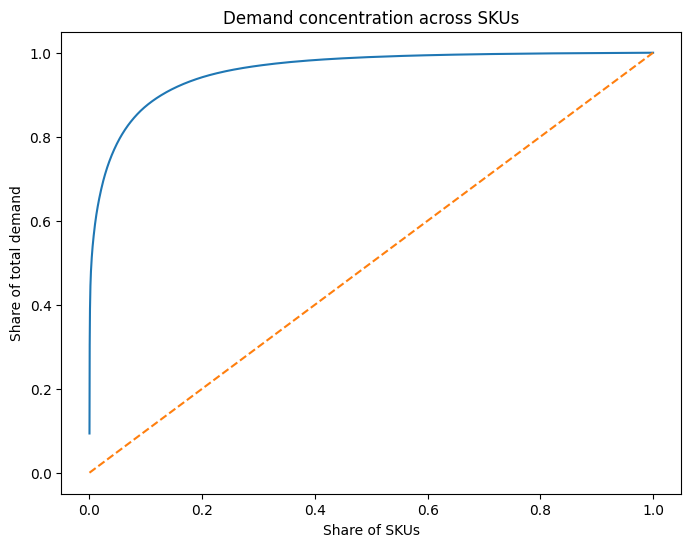

In [50]:
sku_summary["cumulative_demand_share"] = (
    sku_summary["total_demand"].cumsum()
    / sku_summary["total_demand"].sum()
)

sku_summary["cumulative_sku_share"] = (
    np.arange(1, len(sku_summary) + 1)
    / len(sku_summary)
)

plt.figure(figsize=(8, 6))

plt.plot(
    sku_summary["cumulative_sku_share"],
    sku_summary["cumulative_demand_share"]
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Share of SKUs")
plt.ylabel("Share of total demand")
plt.title("Demand concentration across SKUs")

plt.show()

How to interprete the graph?


* The orange dashed line

This is the "no concentration" line.

If demand were spread perfectly evenly:

| Share of SKUs | Share of Demand |
|--------------:|----------------:|
| 10% | 10% |
| 20% | 20% |
| 50% | 50% |
| 100% | 100% |

So the line would follow the diagonal.

* The blue curve

This curve is far above the diagonal. It shoots up almost vertically and then flattens.

For example

1. Around x = 0.01 (This means: Top 1% of SKUs we have: 19,143 SKUs × 1% ≈ 191 SKUs)

Looking at the chart, those 191 SKUs appear to generate roughly: 60% of total demand (That's huge).

2. Around x = 0.10 (This means: Top 10% of SKUs 19,143 × 10% ≈ 1,914 SKUs)

Looking at the chart, they seem to generate about: 85%–90% of total demand

3. Around x = 0.20 (This means: Top 20% of SKUs ≈ 3,829 SKUs)

They appear to generate 95%+ of total demand

The chart  is telling us "Demand is extremely concentrated."

A relatively small number of SKUs account for most of the sales.

### Interpretation

The curve shows that demand is highly concentrated.

If demand were spread evenly across all SKUs, the curve would follow the diagonal line.

Instead, the curve rises sharply at the beginning, indicating that a relatively small number of SKUs account for a large proportion of total demand.

This is important because WMAPE is influenced much more by errors on high-demand SKUs than on low-demand SKUs.

## 11. Classifying Intermittent Demand

Before selecting forecasting models, it is important to understand the type of demand behaviour present in the data.

Many traditional forecasting methods were developed for products that sell regularly every period. However, spare-parts demand is often very different. A part may not sell for many months and then suddenly experience demand. This is known as **intermittent demand**.

For example:

| Month | Demand |
|---------|---------:|
| Jan | 0 |
| Feb | 0 |
| Mar | 3 |
| Apr | 0 |
| May | 0 |
| Jun | 1 |

In this situation, forecasting becomes more difficult because we need to predict both:

1. **When demand will occur**
2. **How much demand will occur**

Researchers Syntetos and Boylan proposed a widely used framework for classifying demand patterns using two measures:

### Average Demand Interval (ADI)

ADI measures how frequently demand occurs.

$$
ADI = \frac{\text{Total periods}}{\text{Number of periods with demand}}
$$

For example, if demand occurs in 6 out of 24 months:

$$
ADI = \frac{24}{6} = 4
$$

This means demand occurs, on average, once every four months.

A high ADI indicates infrequent demand.

---

### Squared Coefficient of Variation (CV²)

CV² measures how variable demand size is when demand occurs.

$$
CV^2 = \left(\frac{\text{Standard Deviation}}{\text{Mean}}\right)^2
$$

A low CV² indicates relatively stable demand quantities.

A high CV² indicates demand quantities vary substantially from one demand occurrence to another.

---

### Demand Classification Matrix

The Syntetos–Boylan framework uses the following thresholds:

- ADI = 1.32
- CV² = 0.49

These thresholds divide demand into four categories:

| | CV² ≤ 0.49 | CV² > 0.49 |
|---|---|---|
| **ADI ≤ 1.32** | Smooth | Erratic |
| **ADI > 1.32** | Intermittent | Lumpy |

#### Smooth
Demand occurs regularly and demand quantities are relatively stable.

#### Intermittent
Demand occurs infrequently but quantities are relatively stable when demand occurs.

#### Erratic
Demand occurs regularly but quantities vary significantly.

#### Lumpy
Demand occurs infrequently and quantities vary significantly.

Lumpy demand is generally considered the most difficult type of demand to forecast.

---

### Why does this matter?

Understanding the distribution of demand types helps explain why some forecasting methods perform better than others.

For example:

- Smooth demand can often be forecast accurately using traditional statistical methods.
- Intermittent and lumpy demand are much more challenging because demand occurs irregularly.
- Modern global forecasting models such as Moirai can learn patterns across thousands of SKUs simultaneously and may perform better on sparse and intermittent demand series.

In the next section we classify each SKU using the Syntetos–Boylan framework and examine the demand patterns present in the Suzuki spare-parts dataset.

## 12. Classify SKU demand patterns

We classify each SKU based on how often demand occurs and how variable demand is when it occurs.

This is not required by the forecasting model itself, but it helps us understand the problem and later compare model performance across different types of SKUs.

In [51]:
def classify_demand(group):
    demand = group["demand"].values
    total_months = len(demand)
    demand_months = demand[demand > 0]

    if len(demand_months) == 0:
        return pd.Series({
            "average_demand_interval": np.inf,
            "squared_coefficient_of_variation": np.nan,
            "demand_type": "No demand observed"
        })

    average_demand_interval = total_months / len(demand_months)

    if len(demand_months) == 1:
        squared_coefficient_of_variation = np.nan
    else:
        squared_coefficient_of_variation = (
            demand_months.std(ddof=1) / demand_months.mean()
        ) ** 2

    if average_demand_interval <= 1.32 and (
        pd.isna(squared_coefficient_of_variation) or squared_coefficient_of_variation <= 0.49
    ):
        demand_type = "Smooth"
    elif average_demand_interval > 1.32 and (
        pd.isna(squared_coefficient_of_variation) or squared_coefficient_of_variation <= 0.49
    ):
        demand_type = "Intermittent"
    elif average_demand_interval <= 1.32 and squared_coefficient_of_variation > 0.49:
        demand_type = "Erratic"
    else:
        demand_type = "Lumpy"

    return pd.Series({
        "average_demand_interval": average_demand_interval,
        "squared_coefficient_of_variation": squared_coefficient_of_variation,
        "demand_type": demand_type
    })


sku_demand_type = (
    sales
    .groupby("sku_id")
    .apply(classify_demand)
    .reset_index()
)

sku_profile = sku_summary.merge(sku_demand_type, on="sku_id", how="left")

type_summary = (
    sku_profile
    .groupby("demand_type", as_index=False)
    .agg(
        number_of_skus=("sku_id", "count"),
        total_demand=("total_demand", "sum"),
        median_zero_month_share=("zero_month_share", "median"),
        median_average_demand_interval=("average_demand_interval", "median")
    )
)

type_summary["sku_share"] = type_summary["number_of_skus"] / type_summary["number_of_skus"].sum()
type_summary["demand_share"] = type_summary["total_demand"] / type_summary["total_demand"].sum()

display(type_summary.sort_values("number_of_skus", ascending=False))

,demand_type,number_of_skus,total_demand,median_zero_month_share,median_average_demand_interval,sku_share,demand_share
1,Intermittent,15534,217292.0,0.907407,10.800000,0.811472,0.098339
2,Lumpy,1555,132675.0,0.634921,2.739130,0.081231,0.060044
4,Smooth,1303,1396701.0,0.054054,1.057143,0.068067,0.632098
0,Erratic,699,462959.0,0.101695,1.113208,0.036515,0.209519
3,No demand observed,52,0.0,1.000000,inf,0.002716,0.000000


### How common is each demand type?

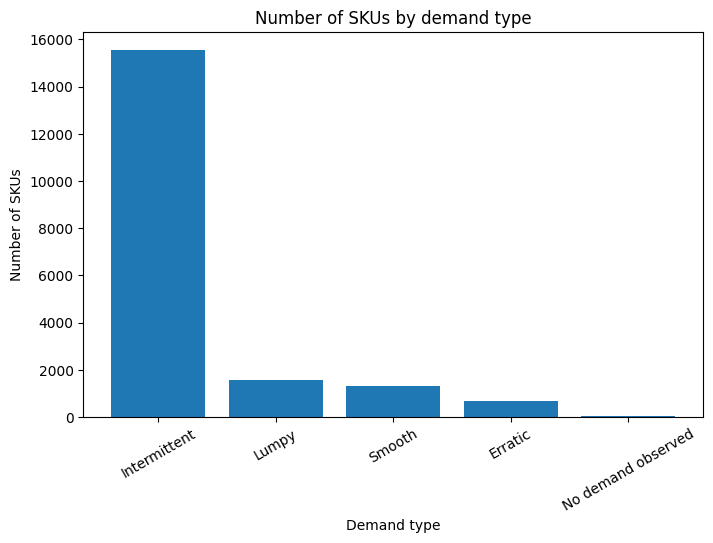

In [52]:
type_summary = type_summary.sort_values("number_of_skus", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(type_summary["demand_type"], type_summary["number_of_skus"])

plt.title("Number of SKUs by demand type")
plt.xlabel("Demand type")
plt.ylabel("Number of SKUs")
plt.xticks(rotation=30)

plt.show()

The chart says roughly:

| Demand Type  | Approximate Number of SKUs |
| ------------ | -------------------------: |
| Intermittent |                    ~15,500 |
| Lumpy        |                     ~1,600 |
| Smooth       |                     ~1,300 |
| Erratic      |                       ~700 |
| No demand    |                        ~50 |

Most Suzuki spare parts are intermittent-demand products.

This is actually a very important finding.


## 14. Inspect example SKUs from each demand type

The demand-type classifications are based on summary statistics, but it is important to validate that they make intuitive sense.

In this section, we plot example SKUs from each demand type and inspect their monthly demand patterns.

Questions to consider:

- Does the demand pattern match the assigned demand type?
- How easy would it be to forecast this SKU?
- Which demand types appear most challenging?
- Do the demand patterns support the conclusions from the ADI and CV² analysis?

This exercise helps build intuition about the forecasting problem before applying forecasting models such as Moirai.

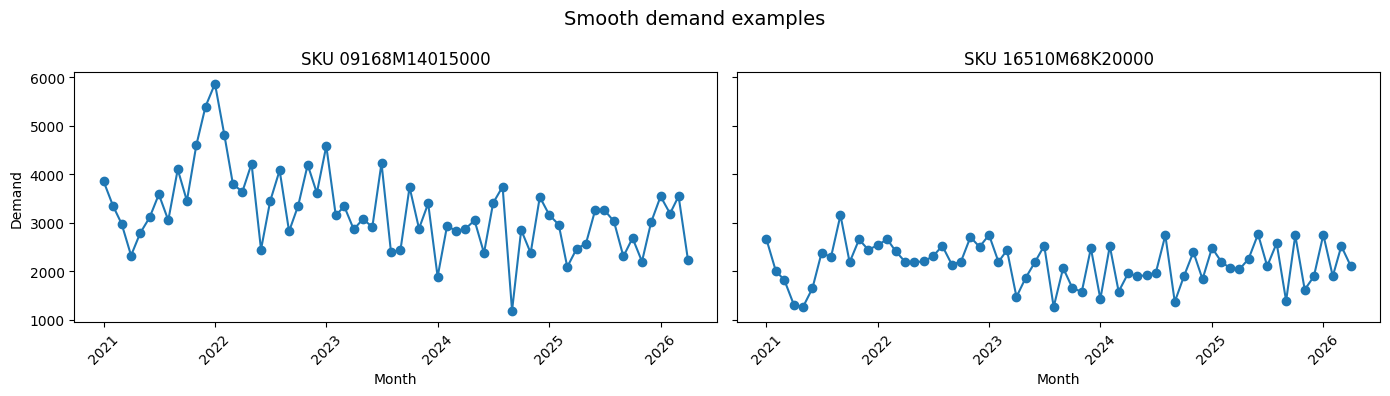

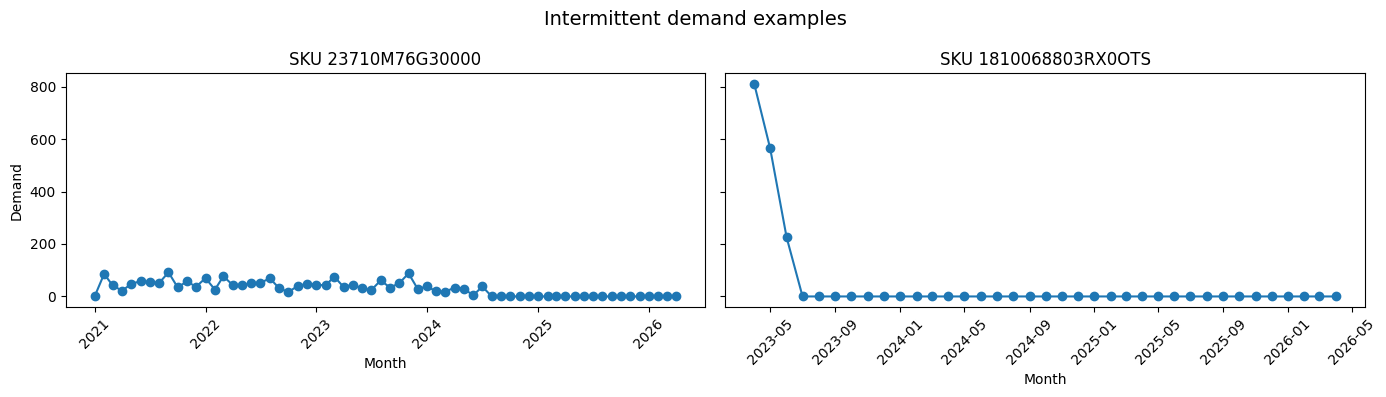

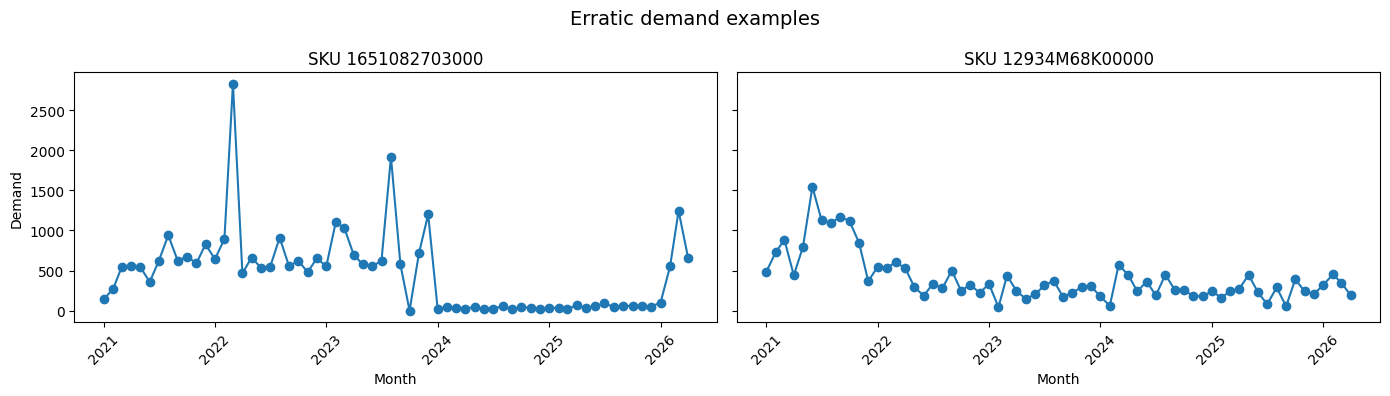

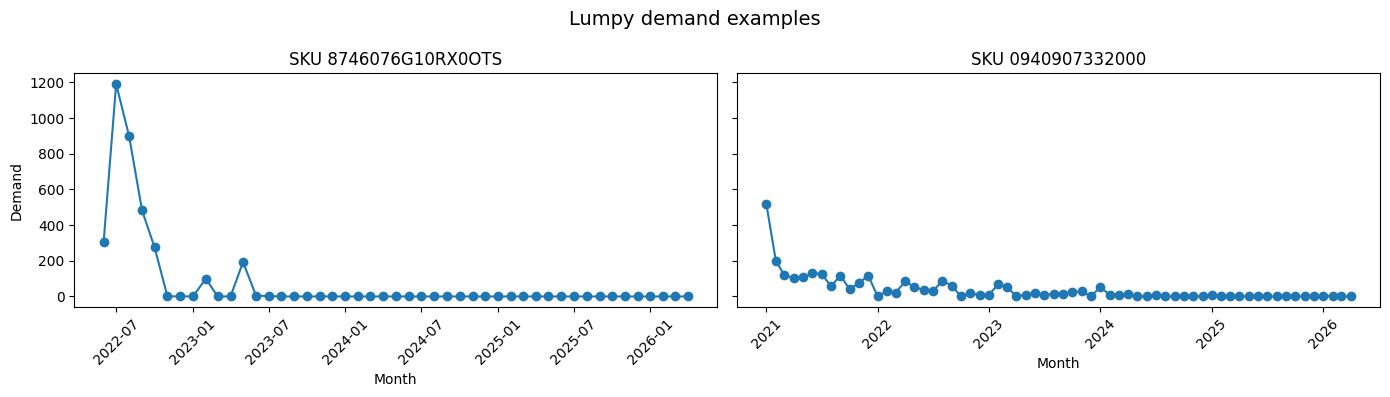

In [53]:
def plot_example_skus(demand_type, n=2):

    example_skus = (
        sku_profile
        .loc[sku_profile["demand_type"] == demand_type]
        .sort_values("total_demand", ascending=False)
        .head(n)["sku_id"]
        .tolist()
    )

    if len(example_skus) == 0:
        print(f"No SKUs found for demand type: {demand_type}")
        return

    fig, axes = plt.subplots(
        1,
        len(example_skus),
        figsize=(14, 4),
        sharey=True
    )

    if len(example_skus) == 1:
        axes = [axes]

    for ax, sku in zip(axes, example_skus):

        sku_data = (
            sales[sales["sku_id"] == sku]
            .sort_values("month")
        )

        ax.plot(
            sku_data["month"],
            sku_data["demand"],
            marker="o"
        )

        ax.set_title(f"SKU {sku}")
        ax.set_xlabel("Month")
        ax.tick_params(axis="x", rotation=45)

    axes[0].set_ylabel("Demand")

    fig.suptitle(f"{demand_type} demand examples", fontsize=14)

    plt.tight_layout()
    plt.show()


for demand_type in ["Smooth", "Intermittent", "Erratic", "Lumpy"]:
    plot_example_skus(demand_type)

#An investigation into the best models for Lumpy and erratic demand types

As noted earlier, it makes sense to group SKUs into demand type and then predict using models that are chosen and tuned for those specific groups. As such, in this section, we will focus on erratic and lumpy demand. Let's begin by examing erratic demand.

##Erratic Demand

Erratic demand has the smallest number of SKUs, not counting SKUs with no demand. Their quantities vary significantly which suggests low autocorrelation but let's check this is the case and compare their autocorrelation with the data as a whole:

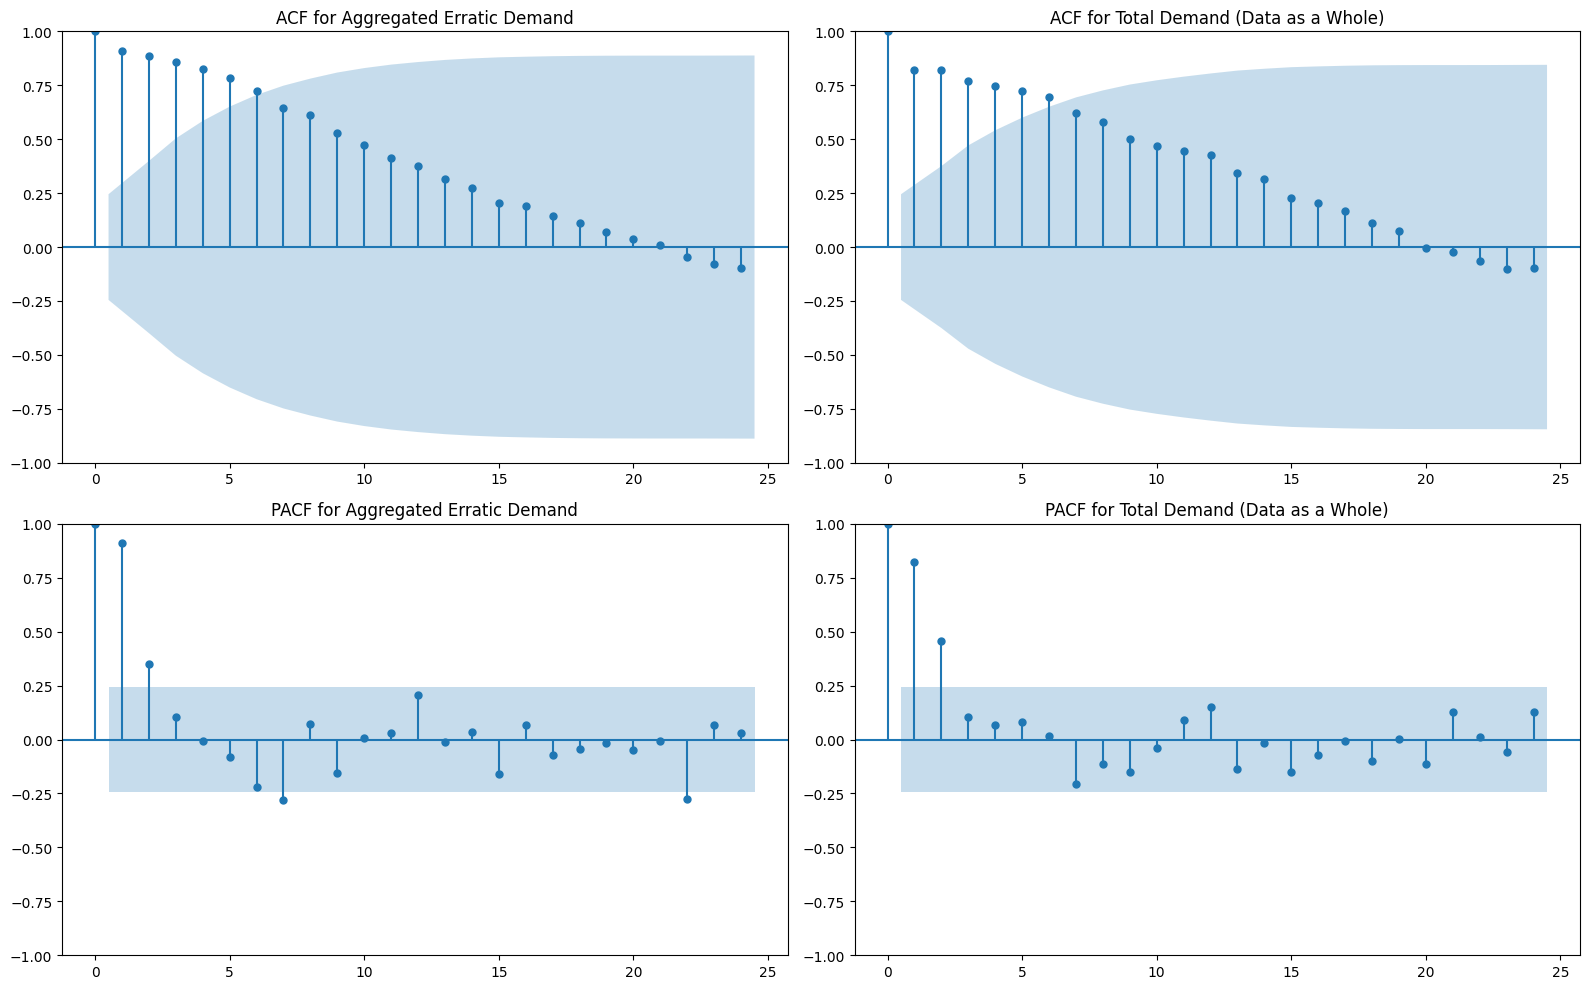

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. Get SKUs classified as 'Erratic'
erratic_skus = sku_profile[sku_profile['demand_type'] == 'Erratic']['sku_id']

# 2. Filter sales data for these erratic SKUs
erratic_sales = sales[sales['sku_id'].isin(erratic_skus)]

# 3. Aggregate erratic demand by month to create a single time series
erratic_monthly_total = erratic_sales.groupby('month')['demand'].sum().reset_index()

# Ensure the 'total_demand' column name is consistent if needed (monthly_total already has it)
erratic_monthly_total = erratic_monthly_total.rename(columns={'demand': 'total_demand'})

# Set up the plots for comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot ACF for Erratic Demand
plot_acf(erratic_monthly_total['total_demand'], ax=axes[0, 0], lags=24)
axes[0, 0].set_title('ACF for Aggregated Erratic Demand')

# Plot PACF for Erratic Demand
plot_pacf(erratic_monthly_total['total_demand'], ax=axes[1, 0], lags=24)
axes[1, 0].set_title('PACF for Aggregated Erratic Demand')

# Plot ACF for Total Demand (Data as a Whole)
plot_acf(monthly_total['total_demand'], ax=axes[0, 1], lags=24)
axes[0, 1].set_title('ACF for Total Demand (Data as a Whole)')

# Plot PACF for Total Demand (Data as a Whole)
plot_pacf(monthly_total['total_demand'], ax=axes[1, 1], lags=24)
axes[1, 1].set_title('PACF for Total Demand (Data as a Whole)')

plt.tight_layout()
plt.show()

Contrary to what we assumed, erratic demand seems have a similar PACF and ACF as the data as a whole at earlier lags, with the first two lags being significant. Additionally, erratic demand shows significant negative PACF at later lags.

####Benchmarking

Let's create some simple models to compare our more complex models against as well as defining our WMAPE function and rolling-origin validation strategy.

In [25]:
def wmape(months, y_true, y_pred):
    """
    Calculates WMAPE using the same definition as monthly_wmape_from_forecasts():

    1. Compute WMAPE separately for each month:
           sum(|actual - forecast|) / sum(actual)

    2. Compute a 3-month rolling average of the monthly WMAPEs.

    3. Return the mean of the rolling WMAPEs as a percentage.

    Args:
        months (pd.Series or array-like): Month corresponding to each observation.
        y_true (pd.Series or np.array): Actual demand values.
        y_pred (pd.Series or np.array): Forecast values.

    Returns:
        float: Mean 3-month rolling WMAPE (%).
    """

    df = pd.DataFrame({
        'month': pd.to_datetime(months),
        'actual': np.asarray(y_true),
        'forecast': np.asarray(y_pred)
    })

    # Absolute error for each SKU/month
    df['absolute_error'] = np.abs(df['actual'] - df['forecast'])

    # Monthly totals
    monthly = (
        df.groupby('month')
          .agg(
              actual_total=('actual', 'sum'),
              absolute_error=('absolute_error', 'sum')
          )
          .sort_index()
    )

    # Monthly WMAPE
    monthly['monthly_wmape'] = np.where(
        monthly['actual_total'] > 0,
        monthly['absolute_error'] / monthly['actual_total'],
        np.nan
    )

    # 3-month rolling mean
    monthly['rolling_3m_wmape'] = (
        monthly['monthly_wmape']
        .rolling(window=3, min_periods=1)
        .mean()
    )

    # Return mean rolling WMAPE as a percentage
    return monthly['rolling_3m_wmape'].mean(skipna=True) * 100

def rolling_origin_validation(data_df, model_func, horizon=1, initial_train_months=36):
    """
    Performs rolling-origin (walk-forward) validation for time series forecasting.

    Args:
        data_df (pd.DataFrame): DataFrame containing 'month', 'sku_id', and 'demand' columns.
                                Assumes data is sorted by sku_id and month.
        model_func (callable): A function that takes train_df and returns a forecast for the next `horizon` periods.
                                The model_func should return a DataFrame with 'sku_id', 'month', 'demand' (forecast) columns.
        horizon (int): The number of months to forecast into the future at each step.
        initial_train_months (int): The minimum number of months for the initial training set.

    Returns:
        pd.DataFrame: DataFrame containing actual and forecasted values for each SKU and month.
    """
    results = []
    all_months = sorted(data_df['month'].unique())

    if len(all_months) < initial_train_months + horizon:
        print("Not enough data for the specified initial training months and horizon.")
        return pd.DataFrame()

    # Determine the start month for the first test set
    first_test_month_idx = initial_train_months

    while first_test_month_idx < len(all_months):
        train_end_month = all_months[first_test_month_idx - 1]
        test_start_month = all_months[first_test_month_idx]

        # Define training and testing periods
        train_df = data_df[data_df['month'] <= train_end_month]
        test_df = data_df[data_df['month'] >= test_start_month]

        # Limit test_df to the current horizon
        test_months_in_horizon = all_months[first_test_month_idx : first_test_month_idx + horizon]
        test_df = test_df[test_df['month'].isin(test_months_in_horizon)]

        if test_df.empty:
            break

        # Generate forecasts using the provided model function
        forecast_df = model_func(train_df, test_months_in_horizon)

        # Merge forecasts with actuals for evaluation
        evaluation_df = pd.merge(
            test_df[['sku_id', 'month', 'demand']],
            forecast_df[['sku_id', 'month', 'demand']].rename(columns={'demand': 'forecast'}),
            on=['sku_id', 'month'],
            how='left'
        )

        # Fill NaNs in forecast with 0 if an SKU is not forecasted for a particular month
        evaluation_df['forecast'] = evaluation_df['forecast'].fillna(0)

        results.append(evaluation_df)

        # Move the origin forward by the horizon length
        first_test_month_idx += horizon

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


# --- Benchmark Model 1: Naïve Forecast (Last Observed Value) ---
def naive_forecast_model(train_df, forecast_months):
    """
    Implements the Naïve forecast: uses the last observed demand for each SKU.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        if not sku_train_df.empty:
            last_demand = sku_train_df['demand'].iloc[-1]
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
        else:
            # If SKU has no history in train_df, forecast 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})

    return pd.DataFrame(forecasts)


# Filter sales data to include only 'Erratic' SKUs
# Ensure 'sales' DataFrame is available from previous steps
if 'sales' not in locals():
    print("Error: 'sales' DataFrame not found. Please ensure previous cells were run.")
    # Fallback or exit strategy if sales is not defined
    # For now, assuming sales is defined from context.

erratic_sku_ids = sku_profile[sku_profile['demand_type'] == 'Erratic']['sku_id'].unique()
erratic_sales_data = sales[sales['sku_id'].isin(erratic_sku_ids)]

print("Running Naïve forecast validation...")
naive_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=naive_forecast_model,
    horizon=1, # Forecast one month ahead at each step
    initial_train_months=36 # Use 3 years of data for initial training
)

# Calculate WMAPE for Naïve forecast
if not naive_results.empty:
    naive_wmape = wmape(naive_results['demand'], naive_results['forecast'], naive_results['demand'])
    print(f"Naïve Forecast WMAPE for Erratic Demand: {naive_wmape:.2f}%")
else:
    print("Naïve forecast results are empty.")

Running Naïve forecast validation...
Naïve Forecast WMAPE for Erratic Demand: 117.14%


In [ ]:
import numpy as np

# --- Benchmark Model 2: Seasonal Naïve Forecast (Last Observed Seasonal Value) ---
def seasonal_naive_forecast_model(train_df, forecast_months, seasonal_period=12):
    """
    Implements the Seasonal Naïve forecast: uses the last observed value from the same season.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.
        seasonal_period (int): The length of the seasonal cycle (e.g., 12 for yearly seasonality).

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        if not sku_train_df.empty:
            # Get the last observed month in the training data
            last_train_month = sku_train_df['month'].iloc[-1]

            for forecast_month in forecast_months:
                # Find the month `seasonal_period` periods ago relative to the forecast_month
                # Use pandas.DateOffset to subtract months safely
                seasonal_lag_month = forecast_month - pd.DateOffset(months=seasonal_period)

                # Find the demand for the seasonal lag month within the training data
                seasonal_demand_row = sku_train_df[sku_train_df['month'] == seasonal_lag_month]

                if not seasonal_demand_row.empty:
                    seasonal_demand = seasonal_demand_row['demand'].iloc[0]
                    forecasts.append({'sku_id': sku, 'month': forecast_month, 'demand': seasonal_demand})
                else:
                    # Fallback to Naive (last observed) if seasonal lag is not available
                    # or forecast 0 if no history at all for the SKU in train_df
                    last_observed_demand = sku_train_df['demand'].iloc[-1]
                    forecasts.append({'sku_id': sku, 'month': forecast_month, 'demand': last_observed_demand})
        else:
            # If SKU has no history in train_df, forecast 0
            for forecast_month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': forecast_month, 'demand': 0})

    return pd.DataFrame(forecasts)

print("Running Seasonal Naïve forecast validation...")
seasonal_naive_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=seasonal_naive_forecast_model,
    horizon=1, # Forecast one month ahead at each step
    initial_train_months=36 # Use 3 years of data for initial training
)

# Calculate WMAPE for Seasonal Naïve forecast
if not seasonal_naive_results.empty:
    seasonal_naive_wmape = wmape(seasonal_naive_results['demand'], seasonal_naive_results['forecast'], seasonal_naive_results['demand'])
    print(f"Seasonal Naïve Forecast WMAPE for Erratic Demand: {seasonal_naive_wmape:.2f}%")
else:
    print("Seasonal Naïve forecast results are empty.")

Running Seasonal Naïve forecast validation...
Seasonal Naïve Forecast WMAPE for Erratic Demand: 148.39%


In [ ]:
# --- Benchmark Model 3: Simple Moving Average (SMA) Forecast ---
def sma_forecast_model(train_df, forecast_months, window_size=3):
    """
    Implements the Simple Moving Average forecast: uses the average of the last `window_size` observed demands.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.
        window_size (int): The number of periods to include in the moving average.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        if not sku_train_df.empty and len(sku_train_df) >= window_size:
            # Calculate SMA from the last `window_size` demands
            sma_value = sku_train_df['demand'].iloc[-window_size:].mean()
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': sma_value})
        elif not sku_train_df.empty:
            # If not enough history for SMA, fall back to Naïve (last observed demand)
            last_demand = sku_train_df['demand'].iloc[-1]
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
        else:
            # If SKU has no history in train_df, forecast 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})

    return pd.DataFrame(forecasts)


print("Running 3-month Simple Moving Average forecast validation...")
sma_3_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=lambda df, months: sma_forecast_model(df, months, window_size=3),
    horizon=1,
    initial_train_months=36
)

# Calculate WMAPE for 3-month SMA forecast
if not sma_3_results.empty:
    sma_3_wmape = wmape(sma_3_results['demand'], sma_3_results['forecast'], sma_3_results['demand'])
    print(f"3-month SMA Forecast WMAPE for Erratic Demand: {sma_3_wmape:.2f}%")
else:
    print("3-month SMA forecast results are empty.")

Running 3-month Simple Moving Average forecast validation...
3-month SMA Forecast WMAPE for Erratic Demand: 70.70%


In [ ]:
print("Running 6-month Simple Moving Average forecast validation...")
sma_6_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=lambda df, months: sma_forecast_model(df, months, window_size=6),
    horizon=1,
    initial_train_months=36
)

# Calculate WMAPE for 6-month SMA forecast
if not sma_6_results.empty:
    sma_6_wmape = wmape(sma_6_results['demand'], sma_6_results['forecast'], sma_6_results['demand'])
    print(f"6-month SMA Forecast WMAPE for Erratic Demand: {sma_6_wmape:.2f}%")
else:
    print("6-month SMA forecast results are empty.")

Running 6-month Simple Moving Average forecast validation...
6-month SMA Forecast WMAPE for Erratic Demand: 69.74%


In [ ]:
# --- Benchmark Model 4: Croston's Method ---
def croston_forecast_model(train_df, forecast_months):
    """
    Implements Croston's Method for intermittent demand forecasting.
    Forecasts average demand interval and average demand size separately.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        demand_occurrences = sku_train_df[sku_train_df['demand'] > 0]['demand']

        if len(demand_occurrences) < 2: # Need at least two demand occurrences to calculate intervals
            # Fallback to Naive (last observed) or 0 if not enough data
            if not sku_train_df.empty:
                last_demand = sku_train_df['demand'].iloc[-1]
            else:
                last_demand = 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
            continue

        # Calculate average demand size
        avg_demand_size = demand_occurrences.mean()

        # Calculate average inter-arrival time (interval)
        # Get indices of demand occurrences
        demand_indices = sku_train_df[sku_train_df['demand'] > 0].index
        # Calculate time differences between demand occurrences
        intervals = (demand_indices[1:] - demand_indices[:-1]).to_series()
        avg_interval = intervals.mean() if not intervals.empty else 1 # Default to 1 if only one occurrence

        # Croston's forecast is average demand size / average interval
        croston_forecast = avg_demand_size / avg_interval if avg_interval > 0 else avg_demand_size # Avoid division by zero
        croston_forecast = max(0, croston_forecast) # Ensure forecast is non-negative

        for month in forecast_months:
            forecasts.append({'sku_id': sku, 'month': month, 'demand': croston_forecast})

    return pd.DataFrame(forecasts)


print("Running Croston's Method forecast validation...")
croston_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=croston_forecast_model,
    horizon=1,
    initial_train_months=36
)

# Calculate WMAPE for Croston's Method
if not croston_results.empty:
    croston_wmape = wmape(croston_results['demand'], croston_results['forecast'], croston_results['demand'])
    print(f"Croston's Method Forecast WMAPE for Erratic Demand: {croston_wmape:.2f}%")
else:
    print("Croston's Method forecast results are empty.")

Running Croston's Method forecast validation...
Croston's Method Forecast WMAPE for Erratic Demand: 358491.14%


In [ ]:
# --- Benchmark Model 5: Syntetos-Boylan Approximation (SBA) ---
def sba_forecast_model(train_df, forecast_months):
    """
    Implements the Syntetos-Boylan Approximation (SBA) for intermittent demand forecasting.
    SBA is an adjusted version of Croston's method.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        demand_occurrences = sku_train_df[sku_train_df['demand'] > 0]['demand']

        if len(demand_occurrences) < 2:
            # Fallback to Naive (last observed) or 0 if not enough data
            if not sku_train_df.empty:
                last_demand = sku_train_df['demand'].iloc[-1]
            else:
                last_demand = 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
            continue

        avg_demand_size = demand_occurrences.mean()

        demand_indices = sku_train_df[sku_train_df['demand'] > 0].index
        intervals = (demand_indices[1:] - demand_indices[:-1]).to_series()
        avg_interval = intervals.mean() if not intervals.empty else 1

        # Croston's forecast
        croston_f = avg_demand_size / avg_interval if avg_interval > 0 else avg_demand_size

        # SBA correction factor
        sba_correction_factor = 1 - (1 / avg_interval)

        # SBA forecast
        sba_forecast = croston_f * sba_correction_factor
        sba_forecast = max(0, sba_forecast) # Ensure forecast is non-negative

        for month in forecast_months:
            forecasts.append({'sku_id': sku, 'month': month, 'demand': sba_forecast})

    return pd.DataFrame(forecasts)


print("Running Syntetos-Boylan Approximation (SBA) forecast validation...")
sba_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=sba_forecast_model,
    horizon=1,
    initial_train_months=36
)

# Calculate WMAPE for SBA
if not sba_results.empty:
    sba_wmape = wmape(sba_results['demand'], sba_results['forecast'], sba_results['demand'])
    print(f"SBA Forecast WMAPE for Erratic Demand: {sba_wmape:.2f}%")
else:
    print("SBA forecast results are empty.")

Running Syntetos-Boylan Approximation (SBA) forecast validation...
SBA Forecast WMAPE for Erratic Demand: 378881.82%


In [ ]:
# --- Benchmark Model 6: Teunter-Syntetos-Babai (TSB) Method ---
def tsb_forecast_model(train_df, forecast_months, alpha=0.1, beta=0.1):
    """
    Implements the Teunter-Syntetos-Babai (TSB) method for intermittent demand forecasting.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.
        alpha (float): Smoothing parameter for demand size (0 to 1).
        beta (float): Smoothing parameter for demand probability (0 to 1).

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        demand_history = sku_train_df['demand'].tolist()

        if len(demand_history) == 0:
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})
            continue

        # Initialize TSB parameters
        Lt = 0 # Smoothed average demand size
        Pt = 0 # Smoothed demand probability
        last_demand_occurrence = -1 # Index of the last demand occurrence
        last_interval = 0 # Length of the last interval without demand

        # Initial values (similar to original TSB implementation, first demand occurrence)
        first_demand_idx = -1
        for i, d in enumerate(demand_history):
            if d > 0:
                first_demand_idx = i
                Lt = d
                Pt = 1.0 # First demand implies probability of 1 for that period
                last_demand_occurrence = i
                break

        if first_demand_idx == -1:
            # No demand observed in history, forecast 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})
            continue

        # Apply TSB smoothing
        for i in range(first_demand_idx + 1, len(demand_history)):
            current_demand = demand_history[i]
            if current_demand > 0:
                # Demand occurred
                Lt = alpha * current_demand + (1 - alpha) * Lt
                interval_since_last_demand = i - last_demand_occurrence
                Pt = beta * (1 / interval_since_last_demand) + (1 - beta) * Pt
                last_demand_occurrence = i
                last_interval = 0
            else:
                # No demand occurred
                last_interval += 1
                Pt = Pt * (1 - beta)

        # Ensure Pt is not zero to avoid division by zero in forecast calculation
        Pt = max(Pt, 1e-6) # Smallest possible positive value

        # TSB forecast
        tsb_forecast_value = Lt * Pt
        tsb_forecast_value = max(0, tsb_forecast_value) # Ensure forecast is non-negative

        for month in forecast_months:
            forecasts.append({'sku_id': sku, 'month': month, 'demand': tsb_forecast_value})

    return pd.DataFrame(forecasts)


print("Running Teunter-Syntetos-Babai (TSB) forecast validation...")
tsb_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=tsb_forecast_model,
    horizon=1,
    initial_train_months=36
)

# Calculate WMAPE for TSB
if not tsb_results.empty:
    tsb_wmape = wmape(tsb_results['demand'], tsb_results['forecast'], tsb_results['demand'])
    print(f"TSB Forecast WMAPE for Erratic Demand: {tsb_wmape:.2f}%")
else:
    print("TSB forecast results are empty.")

Running Teunter-Syntetos-Babai (TSB) forecast validation...
TSB Forecast WMAPE for Erratic Demand: 73.87%


Interestingly, the simple moving average benchmark performs the best which at 61.69% which should inform our subsequent models.

###Pre-processing current features

Now let's pre-process the features given to us in the data frame by removing all columns for which less than 80% of the rows have values for as well as normalisations

In [26]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print("--- Preprocessing for Erratic Demand Models ---")

# FIX: Instead of starting from raw erratic_sales_data, we check if df_preprocessed
# already exists with engineered features. If not, we initialize it.
if 'df_preprocessed' not in locals():
    print("Initializing df_preprocessed from raw data...")
    df_preprocessed = erratic_sales_data.copy()
else:
    print(f"Using existing df_preprocessed with {df_preprocessed.shape[1]} columns.")

# 1. Remove features with more than 20% missing values
missing_percentages = df_preprocessed.isnull().sum() / len(df_preprocessed)
columns_to_drop_missing = missing_percentages[missing_percentages > 0.20].index.tolist()

# We must be careful not to drop the target or critical IDs even if they have missing values (though they shouldn't here)
protected_cols = ['sku_id', 'month', 'demand']
columns_to_drop_missing = [c for c in columns_to_drop_missing if c not in protected_cols]

if columns_to_drop_missing:
    print(f"\nRemoving {len(columns_to_drop_missing)} columns with >20% missing values.")
    df_preprocessed = df_preprocessed.drop(columns=columns_to_drop_missing)

# 2. Apply normalization to numerical features
exclude_from_scaling = [
    'sku_id', 'month', 'demand', 'Date', 'ts_id', 'value',
    'COUNTRY_BRAND_CHANNEL', 'Country', 'Brand', 'Channel',
    'collision_flag', 'collision_flag_clean', 'is_collision'
]

numerical_cols = df_preprocessed.select_dtypes(include=np.number).columns.tolist()
features_to_scale = [col for col in numerical_cols if col not in exclude_from_scaling]

if features_to_scale:
    print(f"Applying StandardScaler to {len(features_to_scale)} features...")
    scaler = StandardScaler()
    df_preprocessed[features_to_scale] = scaler.fit_transform(df_preprocessed[features_to_scale].fillna(0))

print(f"Final shape: {df_preprocessed.shape}")
display(df_preprocessed.head())

--- Preprocessing for Erratic Demand Models ---
Initializing df_preprocessed from raw data...

Removing 14 columns with >20% missing values.
Applying StandardScaler to 28 features...
Final shape: (41546, 43)


,ts_id,COUNTRY_BRAND_CHANNEL,Country,Brand,Channel,Date,STOCK_END_MONTH,STOCK_START_MONTH,NEW_ENTRY_STOCK,Bank_Lending_Rate,Building_Permits,CPI_Transportation,Consumer_Credit,Core_Consumer_Prices,Core_Inflation_Rate,Employed_Persons,Employment_Rate,Food_Inflation,Housing_Index,Imports,Industrial_Production_Mom,Inflation_Rate,Inflation_Rate_MoM,Interest_Rate,Labor_Force_Participation_Rate,Leading_Economic_Index,Private_Sector_Credit,Producer_Prices,Producer_Prices_Change,Retail_Sales_MoM,Total_Vehicle_Sales,Unemployed_Persons,Unemployment_Rate,Wages,REGION,value,collision_flag,sku_id,date,demand,collision_flag_clean,is_collision,month
12,0834131059000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2022-12-01,-0.135217,-0.132685,0.049135,1.314968,4.205140,0.494211,0.381992,0.130715,1.374284,0.157167,0.190377,2.511971,0.367087,0.188835,1.668215,1.957957,-0.416259,1.524110,0.210226,-0.903403,0.255755,-0.041086,-0.726041,-0.272530,0.746427,-0.275992,-0.385113,0.200264,AMERICAS,14.0,NON COLLISION,0834131059000,2022-12-01,14.0,NON COLLISION,False,2022-12-01
21,0915912057000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2021-01-01,-0.135217,-0.132685,-0.209592,-1.244468,-1.841460,-3.666504,-0.183629,-0.427385,-1.798732,-0.350662,-0.225663,-0.093337,0.094223,-1.003275,2.319953,-0.898017,0.419821,-1.632004,-0.023933,-1.220543,-0.396226,-1.184861,0.063967,-0.536412,-0.398886,0.705048,1.029806,-0.286955,AMERICAS,1.0,NON COLLISION,0915912057000,2021-01-01,1.0,NON COLLISION,False,2021-01-01
45,0928332042000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2021-04-01,-0.135217,-0.132685,3.492184,-1.428411,1.406871,-0.601096,-0.175819,-0.398220,-0.749649,-0.361068,-0.245475,-0.503720,0.205390,-0.565614,-0.168501,-0.839131,-0.207239,-1.632004,-0.046594,2.230695,-0.354492,-0.886052,1.197458,-2.066928,-0.109998,0.703578,1.035776,-0.221807,AMERICAS,187.0,NON COLLISION,0928332042000,2021-04-01,187.0,NON COLLISION,False,2021-04-01
46,0928332042000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2026-01-01,1.390579,0.395747,1.283060,-0.485046,-0.192061,0.414391,0.814311,0.649046,-0.801183,0.480866,0.358774,-0.645177,-2.747604,0.352164,-0.583244,-0.986346,-0.207239,-0.457636,0.368849,-0.698194,0.604597,1.327007,0.235708,-0.114200,-0.358311,0.296030,-0.122428,0.777995,AMERICAS,22.0,NON COLLISION,0928332042000,2026-01-01,22.0,NON COLLISION,False,2026-01-01
49,0928335052000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2022-11-01,-0.135217,-0.132685,-0.090179,1.209858,0.274271,0.517190,0.358028,0.124087,1.687168,0.107733,0.150754,2.423366,0.411553,0.518093,-0.464746,2.105172,1.046880,1.524110,0.172458,-1.257854,0.245052,0.274781,0.175599,-1.222505,0.069325,-0.263740,-0.331382,0.155950,AMERICAS,7.0,NON COLLISION,0928335052000,2022-11-01,7.0,NON COLLISION,False,2022-11-01


###XGBOOST

Given what we have found from our exploratory data analysis and our benchmarking, let's implement an XGBOOST model with all lags inputted as features as well as a 6 month moving average. Let's also create the features, zero_streak (as negative PACF at certain lags implies long periods of low demand may result in high demand) and various short term demand vs long term demand comparisons to capture the relationship shown in the PACF plot.

In [27]:
import pandas as pd
import numpy as np

def engineer_features(df):
    """
    Engineers a set of time series features for an SKU-level demand forecasting model.
    """
    df = df.copy()
    df['month'] = pd.to_datetime(df['month'])
    df = df.sort_values(by=['sku_id', 'month']).reset_index(drop=True)

    print("Generating lag features...")
    for i in range(1, 25):
        df[f'lag_{i}'] = df.groupby('sku_id')['demand'].shift(i)

    print("Generating rolling mean features...")
    df['rolling_mean_6'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=6, min_periods=1).mean().shift(1))
    df['rolling_mean_3'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=3, min_periods=1).mean().shift(1))
    df['rolling_mean_12'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=12, min_periods=1).mean().shift(1))
    df['rolling_mean_24'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=24, min_periods=1).mean().shift(1))

    epsilon = 1e-6
    print("Generating rolling mean ratio and difference features...")
    df['rolling_mean_3_div_12'] = df['rolling_mean_3'] / (df['rolling_mean_12'] + epsilon)
    df['rolling_mean_6_div_24'] = df['rolling_mean_6'] / (df['rolling_mean_24'] + epsilon)
    df['rolling_mean_3_minus_12'] = df['rolling_mean_3'] - df['rolling_mean_12']
    df['rolling_mean_6_minus_24'] = df['rolling_mean_6'] - df['rolling_mean_24']

    print("Generating zero streak feature...")
    df['zero_streak'] = df.groupby('sku_id')['demand'].transform(
        lambda x: (x == 0).cumsum() - (x == 0).cumsum().where(x > 0).ffill().fillna(0)
    ).shift(1).fillna(0).astype(int)

    return df

if 'erratic_sales_data' in locals():
    print("Starting feature engineering...")
    # Generate features
    engineered_df = engineer_features(erratic_sales_data)

    # Identify the new columns created
    new_cols = [c for c in engineered_df.columns if c not in erratic_sales_data.columns]

    # Append these features to df_preprocessed based on sku_id and month
    if 'df_preprocessed' in locals():
        print("Merging engineered features into df_preprocessed...")
        df_preprocessed = pd.merge(
            df_preprocessed,
            engineered_df[['sku_id', 'month'] + new_cols],
            on=['sku_id', 'month'],
            how='left'
        )
        print(f"Feature engineering complete. df_preprocessed now has {df_preprocessed.shape[1]} columns.")
        display(df_preprocessed.head())
    else:
        print("Warning: df_preprocessed not found. Storing result in erratic_sales_features instead.")
        erratic_sales_features = engineered_df
else:
    print("Error: 'erratic_sales_data' not found.")

Starting feature engineering...
Generating lag features...
Generating rolling mean features...
Generating rolling mean ratio and difference features...
Generating zero streak feature...
Merging engineered features into df_preprocessed...
Feature engineering complete. df_preprocessed now has 76 columns.


,ts_id,COUNTRY_BRAND_CHANNEL,Country,Brand,Channel,Date,STOCK_END_MONTH,STOCK_START_MONTH,NEW_ENTRY_STOCK,Bank_Lending_Rate,Building_Permits,CPI_Transportation,Consumer_Credit,Core_Consumer_Prices,Core_Inflation_Rate,Employed_Persons,Employment_Rate,Food_Inflation,Housing_Index,Imports,Industrial_Production_Mom,Inflation_Rate,Inflation_Rate_MoM,Interest_Rate,Labor_Force_Participation_Rate,Leading_Economic_Index,Private_Sector_Credit,Producer_Prices,Producer_Prices_Change,Retail_Sales_MoM,Total_Vehicle_Sales,Unemployed_Persons,Unemployment_Rate,Wages,REGION,value,collision_flag,sku_id,date,demand,collision_flag_clean,is_collision,month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean_6,rolling_mean_3,rolling_mean_12,rolling_mean_24,rolling_mean_3_div_12,rolling_mean_6_div_24,rolling_mean_3_minus_12,rolling_mean_6_minus_24,zero_streak
0,0834131059000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2022-12-01,-0.135217,-0.132685,0.049135,1.314968,4.205140,0.494211,0.381992,0.130715,1.374284,0.157167,0.190377,2.511971,0.367087,0.188835,1.668215,1.957957,-0.416259,1.524110,0.210226,-0.903403,0.255755,-0.041086,-0.726041,-0.272530,0.746427,-0.275992,-0.385113,0.200264,AMERICAS,14.0,NON COLLISION,0834131059000,2022-12-01,14.0,NON COLLISION,False,2022-12-01,2.0,2.0,20.0,23.0,22.0,23.0,39.0,0.0,67.0,6.0,17.0,0.0,2.0,7.0,1.0,1.0,21.0,23.0,53.0,30.0,0.0,20.0,10.0,NaN,15.333333,8.000000,18.416667,16.913043,0.434389,0.906598,-10.416667,-1.579710,0
1,0915912057000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2021-01-01,-0.135217,-0.132685,-0.209592,-1.244468,-1.841460,-3.666504,-0.183629,-0.427385,-1.798732,-0.350662,-0.225663,-0.093337,0.094223,-1.003275,2.319953,-0.898017,0.419821,-1.632004,-0.023933,-1.220543,-0.396226,-1.184861,0.063967,-0.536412,-0.398886,0.705048,1.029806,-0.286955,AMERICAS,1.0,NON COLLISION,0915912057000,2021-01-01,1.0,NON COLLISION,False,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,0928332042000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2021-04-01,-0.135217,-0.132685,3.492184,-1.428411,1.406871,-0.601096,-0.175819,-0.398220,-0.749649,-0.361068,-0.245475,-0.503720,0.205390,-0.565614,-0.168501,-0.839131,-0.207239,-1.632004,-0.046594,2.230695,-0.354492,-0.886052,1.197458,-2.066928,-0.109998,0.703578,1.035776,-0.221807,AMERICAS,187.0,NON COLLISION,0928332042000,2021-04-01,187.0,NON COLLISION,False,2021-04-01,45.0,81.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.000000,68.000000,68.000000,68.000000,1.000000,1.000000,0.000000,0.000000,0
3,0928332042000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2026-01-01,1.390579,0.395747,1.283060,-0.485046,-0.192061,0.414391,0.814311,0.649046,-0.801183,0.480866,0.358774,-0.645177,-2.747604,0.352164,-0.583244,-0.986346,-0.207239,-0.457636,0.368849,-0.698194,0.604597,1.327007,0.235708,-0.114200,-0.358311,0.296030,-0.122428,0.777995,AMERICAS,22.0,NON COLLISION,0928332042000,2026-01-01,22.0,NON COLLISION,False,2026-01-01,12.0,19.0,60.0,9.0,31.0,27.0,6.0,20.0,35.0,9.0,5.0,37.0,10.0,16.0,8.0,2.0,36.0,28.0,11.0,5.0,30.0,29.0,49.0,8.0,26.333333,30.333333,22.500000,20.916667,1.348148,1.258964,7.833333,5.416667,0
4,0928335052000,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,2022-11-01,-0.135217,-0.132685,-0.090179,1.209858,0.274271,0.517190,0.358028,0.124087,1.687168,0.107733,0.150754,2.423366,0.411553,0.518093,-0.464746,2.105172,1.046880,1.524110,0.172458,-1.257854,0.245052,0.274781,0.175599,-1.222505,0.069325,-0.263740,-0.331382,0.155950,AMERICAS,7.0,NON COLLISION,0928335052000,2022-11-01,7.0,NON COLLISION,False,2022-11-01,4.0,10.0,9.0,12.0,10.0,11.0,12.0,18.0,14.0,0.0,0.0,2.0,2.0,12.0,4.0,19.0,6.0,2.0,14.0,6.0,7.0,4.0,NaN,NaN,9.333333,7.666667,8.500000,8.090909,0.901961,1.153558,-0.833333,1.242424,0


In [28]:
import xgboost as xgb
import pandas as pd
import numpy as np

def xgboost_model_func_preprocessed(train_df, forecast_months):
    """
    XGBoost model function using pre-processed data with One-Hot Encoding and temporal features.
    """
    # filter the global pre-processed features
    train_skus = train_df['sku_id'].unique()
    train_months = train_df['month'].unique()

    # Select relevant data
    data_subset = df_preprocessed[df_preprocessed['sku_id'].isin(train_skus)].copy()

    # 1. Convert Date into usable numerical features
    data_subset['year'] = data_subset['month'].dt.year
    data_subset['month_num'] = data_subset['month'].dt.month

    # 2. One-Hot Encoding for categorical features
    # We select relevant categories that might influence erratic demand
    cats_to_encode = ['Brand', 'Channel']
    data_encoded = pd.get_dummies(data_subset, columns=cats_to_encode, dummy_na=False)

    # Identify feature columns
    # Exclude IDs, raw strings, and the target
    exclude = [
        'sku_id', 'month', 'demand', 'Date', 'ts_id', 'value',
        'collision_flag', 'collision_flag_clean', 'is_collision',
        'COUNTRY_BRAND_CHANNEL', 'Country', 'REGION', 'date'
    ]
    feature_cols = [c for c in data_encoded.columns if c not in exclude]

    # Split into Train and Test
    train_mask = data_encoded['month'].isin(train_months)
    test_mask = data_encoded['month'].isin(forecast_months)

    X_train_full = data_encoded[train_mask]
    X_train_clean = X_train_full.dropna(subset=feature_cols)
    y_train = X_train_clean['demand']
    X_train = X_train_clean[feature_cols]

    if X_train.empty:
        return pd.DataFrame([{'sku_id': s, 'month': m, 'demand': 0} for s in train_skus for m in forecast_months])

    # Train
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    # Prepare Test set
    X_test_full = data_encoded[test_mask]
    X_test = X_test_full[feature_cols].fillna(0)

    if X_test.empty:
        return pd.DataFrame([{'sku_id': s, 'month': m, 'demand': 0} for s in train_skus for m in forecast_months])

    preds = model.predict(X_test)

    results = pd.DataFrame({
        'sku_id': X_test_full['sku_id'],
        'month': X_test_full['month'],
        'demand': preds
    })
    results['demand'] = results['demand'].clip(lower=0)

    return results

print("Running XGBoost validation with One-Hot Encoding and Date features...")
xgb_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=xgboost_model_func_preprocessed,
    horizon=1,
    initial_train_months=36
)

if not xgb_results.empty:
    xgboost_wmape = wmape(xgb_results['demand'], xgb_results['forecast'], xgb_results['demand'])
    print(f"XGBoost WMAPE (with OHE & Date features): {xgboost_wmape:.2f}%")

Running XGBoost validation with One-Hot Encoding and Date features...
XGBoost WMAPE (with OHE & Date features): 37.23%


Now let's incorporate hyperparemeter tuning into the process:

In [29]:
from sklearn.model_selection import GridSearchCV

def get_best_xgboost_params(data_for_tuning, feature_cols, target_col='demand'):
    """
    Performs GridSearchCV to find the best hyperparameters for XGBoost.
    """
    # Drop rows with NaN in features or target before tuning
    data_for_tuning_clean = data_for_tuning.dropna(subset=feature_cols + [target_col])

    if data_for_tuning_clean.empty:
        print("Warning: No clean data available for hyperparameter tuning. Using default parameters.")
        return {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3}

    X_tune = data_for_tuning_clean[feature_cols]
    y_tune = data_for_tuning_clean[target_col]

    # Define a smaller parameter grid for efficiency in a rolling validation context
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }

    print(f"\nStarting GridSearchCV with {len(X_tune)} samples...")
    grid_search = GridSearchCV(
        estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid=param_grid,
        scoring='neg_mean_absolute_error', # Optimize for MAE
        cv=3, # Use 3-fold cross-validation
        verbose=0, # Set to 1 or 2 for more detailed output
        n_jobs=-1 # Use all available cores
    )

    grid_search.fit(X_tune, y_tune)
    print("GridSearchCV completed.")
    print(f"Best parameters found: {grid_search.best_params_}")
    return grid_search.best_params_


def xgboost_model_func_tuned(train_df, forecast_months, best_params):
    """
    XGBoost model function using pre-processed data with One-Hot Encoding and temporal features,
    and incorporating provided best hyperparameters.
    """
    # filter the global pre-processed features
    train_skus = train_df['sku_id'].unique()
    train_months = train_df['month'].unique()

    # Select relevant data from the preprocessed (and externally merged) dataframe
    # Ensure df_preprocessed is globally available or passed as an argument
    data_subset = df_preprocessed[df_preprocessed['sku_id'].isin(train_skus)].copy()

    # 1. Convert Date into usable numerical features if not already done
    if 'year' not in data_subset.columns:
        data_subset['year'] = data_subset['month'].dt.year
    if 'month_num' not in data_subset.columns:
        data_subset['month_num'] = data_subset['month'].dt.month

    # 2. One-Hot Encoding for categorical features (ensure consistency with tuning data)
    cats_to_encode = ['Brand', 'Channel']
    # Use the existing columns in df_preprocessed for dummy columns to avoid issues with missing categories
    # during different folds. This assumes df_preprocessed was dummified at the start or a consistent set of columns.
    # For this demonstration, we'll re-apply dummification to the subset, but in a real system,
    # a consistent dummification across all data (train + test) using the full dataset's categories is better.
    data_encoded = pd.get_dummies(data_subset, columns=cats_to_encode, dummy_na=False)

    # Identify feature columns (must be consistent with tuning features)
    exclude = [
        'sku_id', 'month', 'demand', 'Date', 'ts_id', 'value',
        'collision_flag', 'collision_flag_clean', 'is_collision',
        'COUNTRY_BRAND_CHANNEL', 'Country', 'REGION', 'date'
    ]
    feature_cols = [c for c in data_encoded.columns if c not in exclude and data_encoded[c].dtype != 'object']

    # Split into Train and Test
    X_train_full = data_encoded[data_encoded['month'].isin(train_months)]
    X_test_full = data_encoded[data_encoded['month'].isin(forecast_months)]

    # Align columns for training and test data after one-hot encoding
    # This is crucial if categories differ between splits
    all_feature_columns_seen = sorted(list(set(X_train_full.columns) | set(X_test_full.columns) - set(exclude)))
    final_feature_cols = [col for col in all_feature_columns_seen if col in feature_cols] # Ensure only valid features are kept

    X_train_clean = X_train_full.dropna(subset=final_feature_cols + ['demand'])
    y_train = X_train_clean['demand']
    X_train = X_train_clean[final_feature_cols]

    # Add missing columns to X_train and X_test that might have appeared in OHE from tuning data
    # This handles cases where certain categories are only present in some splits
    missing_in_train = set(final_feature_cols) - set(X_train.columns)
    for c in missing_in_train: X_train[c] = 0
    X_train = X_train[final_feature_cols] # Reorder columns consistently


    if X_train.empty:
        return pd.DataFrame([{'sku_id': s, 'month': m, 'demand': 0} for s in train_skus for m in forecast_months])

    # Train with best parameters
    model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
    model.fit(X_train, y_train)

    # Prepare Test set
    X_test = X_test_full[final_feature_cols].fillna(0) # Fill NaNs in features with 0
    missing_in_test = set(final_feature_cols) - set(X_test.columns)
    for c in missing_in_test: X_test[c] = 0
    X_test = X_test[final_feature_cols] # Reorder columns consistently

    if X_test.empty:
        return pd.DataFrame([{'sku_id': s, 'month': m, 'demand': 0} for s in train_skus for m in forecast_months])

    preds = model.predict(X_test)

    results = pd.DataFrame({
        'sku_id': X_test_full['sku_id'],
        'month': X_test_full['month'],
        'demand': preds
    })
    results['demand'] = results['demand'].clip(lower=0)

    return results


# --- Hyperparameter Tuning ---
# First, define the feature columns for tuning. This should be consistent with the model function.
# Temporarily apply initial date features and OHE to a full copy of erratic_sales_data to get all possible columns.
# This is done to ensure the `feature_cols` passed to `get_best_xgboost_params` capture the full scope.
# In a production setting, a more robust pipeline for feature engineering and column management would be used.

print("\n--- Initial Feature Engineering for Tuning (on a sample of full data) ---")
# Make a copy of df_preprocessed, which now includes all engineered and external features
df_for_tuning = df_preprocessed.copy()

# Ensure date features are present (might already be there from previous steps)
if 'year' not in df_for_tuning.columns:
    df_for_tuning['year'] = df_for_tuning['month'].dt.year
if 'month_num' not in df_for_tuning.columns:
    df_for_tuning['month_num'] = df_for_tuning['month'].dt.month

cats_to_encode_tuning = ['Brand', 'Channel']
# Use pd.get_dummies to get all possible columns for consistent feature selection
df_for_tuning_encoded = pd.get_dummies(df_for_tuning, columns=cats_to_encode_tuning, dummy_na=False)

exclude_tuning = [
    'sku_id', 'month', 'demand', 'Date', 'ts_id', 'value',
    'collision_flag', 'collision_flag_clean', 'is_collision',
    'COUNTRY_BRAND_CHANNEL', 'Country', 'REGION', 'date'
]

# Identify all potential feature columns AFTER dummification and merging external data
all_possible_feature_cols = [c for c in df_for_tuning_encoded.columns if c not in exclude_tuning and df_for_tuning_encoded[c].dtype != 'object']

# Create a tuning data set (e.g., first 36 months of data)
all_months = sorted(df_for_tuning_encoded['month'].unique())
initial_train_months_for_tuning = 36
if len(all_months) > initial_train_months_for_tuning:
    tuning_end_month = all_months[initial_train_months_for_tuning - 1]
    tuning_data_subset = df_for_tuning_encoded[df_for_tuning_encoded['month'] <= tuning_end_month]
else:
    tuning_data_subset = df_for_tuning_encoded.copy() # If not enough data, use all available

best_xgboost_params = get_best_xgboost_params(tuning_data_subset, all_possible_feature_cols)


# --- Run Rolling Origin Validation with Tuned Parameters ---
print("\nRunning XGBoost validation with Tuned Hyperparameters...")
xgb_tuned_results = rolling_origin_validation(
    data_df=erratic_sales_data, # Original data for determining train/test splits
    model_func=lambda train_df_fold, forecast_months_fold: xgboost_model_func_tuned(train_df_fold, forecast_months_fold, best_xgboost_params),
    horizon=1,
    initial_train_months=36
)

if not xgb_tuned_results.empty:
    xgboost_tuned_wmape = wmape(xgb_tuned_results['demand'], xgb_tuned_results['forecast'], xgb_tuned_results['demand'])
    print(f"XGBoost WMAPE (with Tuned Hyperparameters): {xgboost_tuned_wmape:.2f}%")
else:
    print("Tuned XGBoost forecast results are empty or validation failed.")



--- Initial Feature Engineering for Tuning (on a sample of full data) ---

Starting GridSearchCV with 7209 samples...
GridSearchCV completed.
Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Running XGBoost validation with Tuned Hyperparameters...
XGBoost WMAPE (with Tuned Hyperparameters): 38.17%


As we can see, this makes the model perform slightly worse but it still makes sense to use this model going forward otherwise we are effectively introducing bias.

We are now going to incorporate external data into the same model:

In [30]:
# Ensure external_data dates are converted to datetime and aligned to month-start for merging
external_data['month_dt'] = pd.to_datetime(external_data[['year', 'month']].assign(day=1))

# Drop the 'year' and 'month' columns from external_data to avoid duplication after merge
external_features = external_data.drop(columns=['year', 'month'])

# Merge external features into df_preprocessed based on the 'month' column
df_preprocessed = pd.merge(
    df_preprocessed,
    external_features,
    left_on='month',
    right_on='month_dt',
    how='left'
).drop(columns=['month_dt'])

print(f"Merged external data. New feature set shape: {df_preprocessed.shape}")

# Re-run the XGBoost validation with the added external features and TUNED hyperparameters
print("Running XGBoost validation with categorical, date, external features, and TUNED hyperparameters...")
xgb_ext_tuned_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=lambda train_df_fold, forecast_months_fold: xgboost_model_func_tuned(train_df_fold, forecast_months_fold, best_xgboost_params),
    horizon=1,
    initial_train_months=36
)

if not xgb_ext_tuned_results.empty:
    xgboost_ext_tuned_wmape = wmape(xgb_ext_tuned_results['demand'], xgb_ext_tuned_results['forecast'], xgb_ext_tuned_results['demand'])
    print(f"XGBoost WMAPE (with External Features and Tuned Hyperparameters): {xgboost_ext_tuned_wmape:.2f}%")
else:
    print("Validation failed or returned no results.")

Merged external data. New feature set shape: (41546, 110)
Running XGBoost validation with categorical, date, external features, and TUNED hyperparameters...
XGBoost WMAPE (with External Features and Tuned Hyperparameters): 39.04%


### Testing Alternative Ensemble Models: LightGBM and Random Forest

Since XGBoost is an iterative boosting method, we will now test:
1. **LightGBM**: Often faster and more memory-efficient, which helps with 140+ features.
2. **Random Forest**: A bagging-based ensemble that is less prone to overfitting on noisy (erratic) demand data.

In [31]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

def engineer_features_local(df):
    df = df.copy()
    df['month'] = pd.to_datetime(df['month'])
    df = df.sort_values(by=['sku_id', 'month']).reset_index(drop=True)

    for i in range(1, 25):
        df[f'lag_{i}'] = df.groupby('sku_id')['demand'].shift(i)

    df['rolling_mean_6'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=6, min_periods=1).mean().shift(1))
    df['rolling_mean_3'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=3, min_periods=1).mean().shift(1))
    df['rolling_mean_12'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=12, min_periods=1).mean().shift(1))
    df['rolling_mean_24'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=24, min_periods=1).mean().shift(1))

    epsilon = 1e-6
    df['rolling_mean_3_div_12'] = df['rolling_mean_3'] / (df['rolling_mean_12'] + epsilon)
    df['rolling_mean_6_div_24'] = df['rolling_mean_6'] / (df['rolling_mean_24'] + epsilon)
    df['rolling_mean_3_minus_12'] = df['rolling_mean_3'] - df['rolling_mean_12']
    df['rolling_mean_6_minus_24'] = df['rolling_mean_6'] - df['rolling_mean_24']

    df['zero_streak'] = df.groupby('sku_id')['demand'].transform(
        lambda x: (x == 0).cumsum() - (x == 0).cumsum().where(x > 0).ffill().fillna(0)
    ).shift(1).fillna(0).astype(int)
    return df

# --- FIX: Ensure features are merged correctly ---
if 'erratic_sales_data' in locals():
    engineered_df = engineer_features_local(erratic_sales_data)
    new_cols = [c for c in engineered_df.columns if c not in erratic_sales_data.columns]

    df_preprocessed = pd.merge(
        df_preprocessed[[c for c in df_preprocessed.columns if c not in new_cols]],
        engineered_df[['sku_id', 'month'] + new_cols],
        on=['sku_id', 'month'],
        how='left'
    )

# Re-prepare and Merge external features properly
external_data['month_dt'] = pd.to_datetime(external_data[['year', 'month']].assign(day=1))
external_raw_names = [c for c in external_data.columns if c not in ['year', 'month', 'month_dt']]

# Ensure we only merge the macro columns
external_features_subset = external_data[['month_dt'] + external_raw_names]

df_preprocessed = pd.merge(
    df_preprocessed[[c for c in df_preprocessed.columns if c not in external_raw_names]],
    external_features_subset,
    left_on='month',
    right_on='month_dt',
    how='left'
).drop(columns=['month_dt'], errors='ignore')

# Re-verify identification
actual_external_cols = [c for c in df_preprocessed.columns if c in external_raw_names]
print(f"Global check: Detected {len(actual_external_cols)} external features.")

def alternative_models_func(train_df, forecast_months, model_type='lgbm', include_external=True):
    train_skus = train_df['sku_id'].unique()
    train_months = train_df['month'].unique()
    data_subset = df_preprocessed[df_preprocessed['sku_id'].isin(train_skus)].copy()

    cats_to_encode = ['Brand', 'Channel']
    data_encoded = pd.get_dummies(data_subset, columns=cats_to_encode, dummy_na=False)

    exclude = ['sku_id', 'month', 'demand', 'Date', 'ts_id', 'value', 'collision_flag', 'collision_flag_clean', 'is_collision', 'COUNTRY_BRAND_CHANNEL', 'Country', 'REGION', 'date', 'month_dt']
    all_numeric = [c for c in data_encoded.columns if c not in exclude and data_encoded[c].dtype != 'object']

    # Use set intersection to ensure we catch actual columns in the encoded dataframe
    ext_found = [c for c in all_numeric if c in actual_external_cols]
    feature_cols = all_numeric if include_external else [c for c in all_numeric if c not in ext_found]

    # Debug: Print feature count once per validation run
    if getattr(alternative_models_func, 'debug_done', False) == False:
        print(f"Training {model_type} (Include Ext: {include_external}) with {len(feature_cols)} features. (Macro count: {len([c for c in feature_cols if c in ext_found])})")
        alternative_models_func.debug_done = True

    train_mask = data_encoded['month'].isin(train_months)
    test_mask = data_encoded['month'].isin(forecast_months)

    X_train = data_encoded[train_mask][feature_cols].fillna(0)
    y_train = data_encoded[train_mask]['demand']
    X_test = data_encoded[test_mask][feature_cols].fillna(0)

    if X_train.empty or X_test.empty: return pd.DataFrame([{'sku_id': s, 'month': m, 'demand': 0} for s in train_skus for m in forecast_months])

    if model_type == 'lgbm':
        model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
    else:
        model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results = pd.DataFrame({'sku_id': data_encoded[test_mask]['sku_id'], 'month': data_encoded[test_mask]['month'], 'demand': preds})
    results['demand'] = results['demand'].clip(lower=0)
    return results

print("--- Starting 4-Way Comparison ---")
alternative_models_func.debug_done = False
print("Processing LGBM Base...")
lgbm_base = rolling_origin_validation(erratic_sales_data, lambda t, f: alternative_models_func(t, f, 'lgbm', False), horizon=1, initial_train_months=36)
print(f"LGBM (Internal): {wmape(lgbm_base['demand'], lgbm_base['forecast'], lgbm_base['demand']):.2f}%")

alternative_models_func.debug_done = False
print("Processing LGBM Full...")
lgbm_full = rolling_origin_validation(erratic_sales_data, lambda t, f: alternative_models_func(t, f, 'lgbm', True), horizon=1, initial_train_months=36)
print(f"LGBM (Internal + External): {wmape(lgbm_full['demand'], lgbm_full['forecast'], lgbm_full['demand']):.2f}%")

alternative_models_func.debug_done = False
print("Processing RF Base...")
rf_base = rolling_origin_validation(erratic_sales_data, lambda t, f: alternative_models_func(t, f, 'rf', False), horizon=1, initial_train_months=36)
print(f"RF (Internal): {wmape(rf_base['demand'], rf_base['forecast'], rf_base['demand']):.2f}%")

alternative_models_func.debug_done = False
print("Processing RF Full...")
rf_full = rolling_origin_validation(erratic_sales_data, lambda t, f: alternative_models_func(t, f, 'rf', True), horizon=1, initial_train_months=36)
print(f"RF (Internal + External): {wmape(rf_full['demand'], rf_full['forecast'], rf_full['demand']):.2f}%")

Global check: Detected 34 external features.
--- Starting 4-Way Comparison ---
Processing LGBM Base...
Training lgbm (Include Ext: False) with 63 features. (Macro count: 0)
LGBM (Internal): 46.33%
Processing LGBM Full...
Training lgbm (Include Ext: True) with 97 features. (Macro count: 34)
LGBM (Internal + External): 46.43%
Processing RF Base...
Training rf (Include Ext: False) with 63 features. (Macro count: 0)
RF (Internal): 47.47%
Processing RF Full...
Training rf (Include Ext: True) with 97 features. (Macro count: 34)
RF (Internal + External): 47.11%


From this, we can see that LightGBM is the winner and it takes far less time to fit. However, it does not beat the XBBOOST method from before

##Lumpy Demand

Let's plot the ACF and PACF for the lumpy demand data just as we did for the erratic demand data


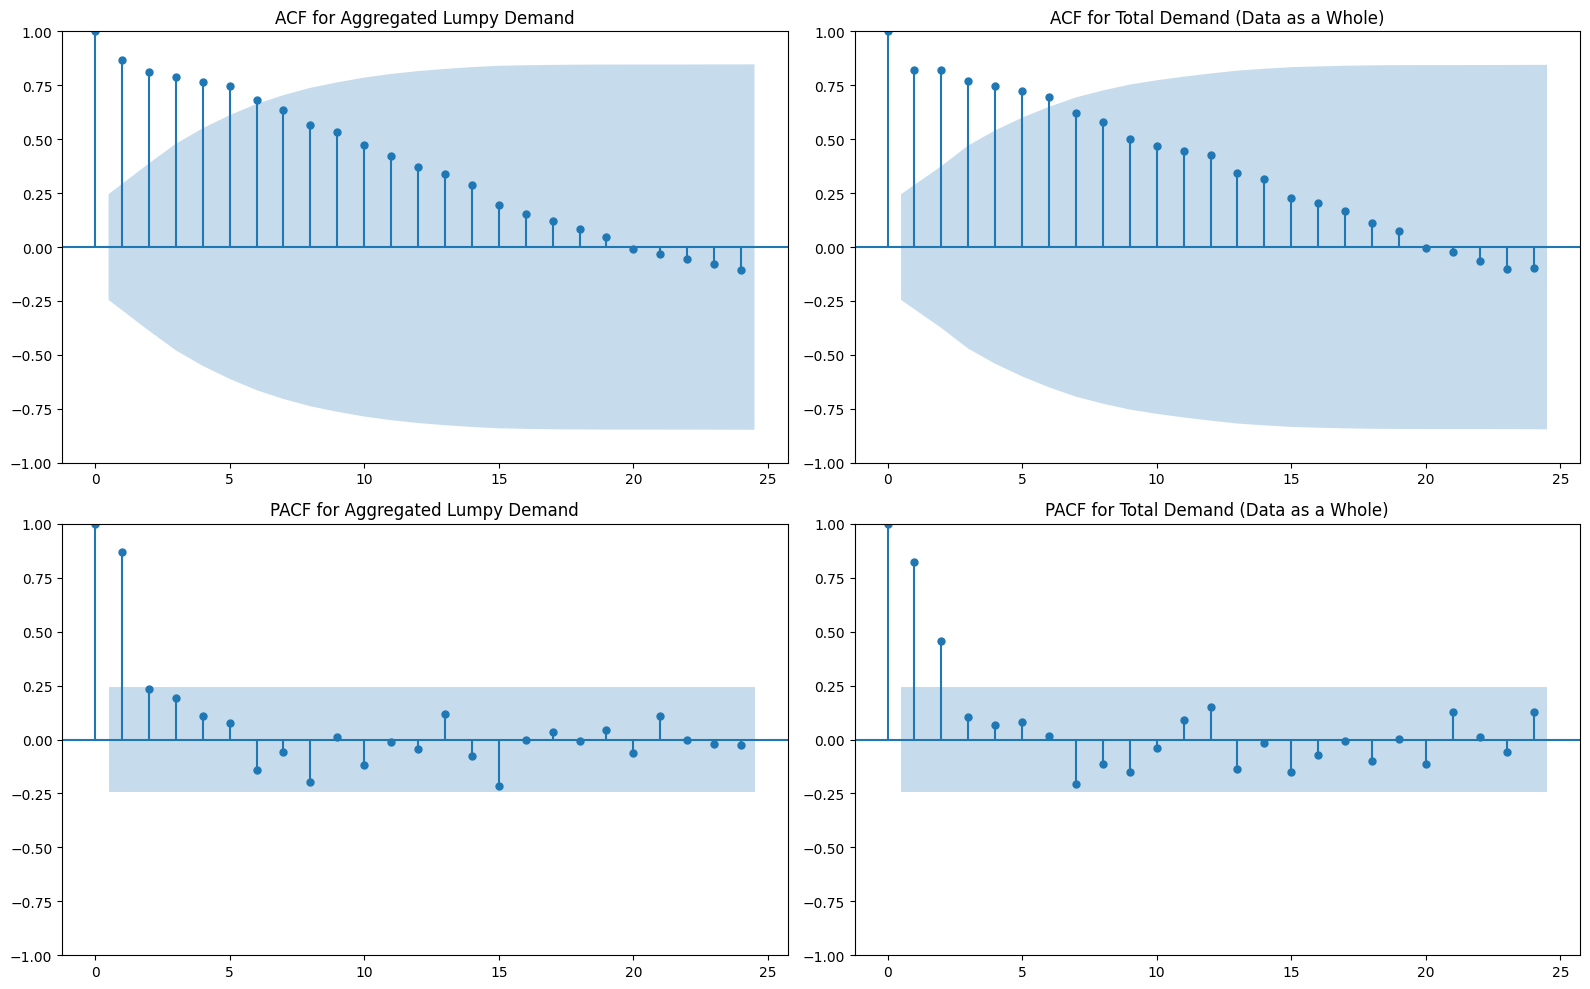

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. Get SKUs classified as 'Lumpy'
lumpy_skus = sku_profile[sku_profile['demand_type'] == 'Lumpy']['sku_id']

# 2. Filter sales data for these lumpy SKUs
lumpy_sales = sales[sales['sku_id'].isin(lumpy_skus)]

# 3. Aggregate lumpy demand by month
lumpy_monthly_total = lumpy_sales.groupby('month')['demand'].sum().reset_index()
lumpy_monthly_total = lumpy_monthly_total.rename(columns={'demand': 'total_demand'})

# 4. Set up the comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot ACF for Lumpy Demand
plot_acf(lumpy_monthly_total['total_demand'], ax=axes[0, 0], lags=24)
axes[0, 0].set_title('ACF for Aggregated Lumpy Demand')

# Plot PACF for Lumpy Demand
plot_pacf(lumpy_monthly_total['total_demand'], ax=axes[1, 0], lags=24)
axes[1, 0].set_title('PACF for Aggregated Lumpy Demand')

# Plot ACF for Total Demand (Reference)
plot_acf(monthly_total['total_demand'], ax=axes[0, 1], lags=24)
axes[0, 1].set_title('ACF for Total Demand (Data as a Whole)')

# Plot PACF for Total Demand (Reference)
plot_pacf(monthly_total['total_demand'], ax=axes[1, 1], lags=24)
axes[1, 1].set_title('PACF for Total Demand (Data as a Whole)')

plt.tight_layout()
plt.show()

As we can see, the PACF decays far faster for lumpy demand than for the rest of the data and there are no lags higher than lag 1 that have partial autocorrelation that is considered significant.

###Pre-Processing



In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def engineer_features_full(df):
    """Engineers features for the full dataset."""
    df = df.copy()
    df['month'] = pd.to_datetime(df['month'])
    df = df.sort_values(by=['sku_id', 'month']).reset_index(drop=True)

    print("Generating lags and rolling features for all SKUs...")
    for i in range(1, 25):
        df[f'lag_{i}'] = df.groupby('sku_id')['demand'].shift(i)

    df['rolling_mean_3'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
    df['rolling_mean_6'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(6, min_periods=1).mean().shift(1))
    df['rolling_mean_12'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(12, min_periods=1).mean().shift(1))
    df['rolling_mean_24'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(24, min_periods=1).mean().shift(1))

    df['zero_streak'] = df.groupby('sku_id')['demand'].transform(
        lambda x: (x == 0).cumsum() - (x == 0).cumsum().where(x > 0).ffill().fillna(0)
    ).shift(1).fillna(0)

    return df

# 1. Combine all modeling data
print("Rebuilding df_preprocessed for Lumpy analysis...")
all_modeling_skus = pd.concat([erratic_sales_data, lumpy_sales_data]).drop_duplicates()

# 2. Filter columns with > 20% missing values (Same rule as erratic data)
missing_percentages = all_modeling_skus.isnull().sum() / len(all_modeling_skus)
protected_cols = ['sku_id', 'month', 'demand', 'Date', 'ts_id', 'value', 'collision_flag', 'is_collision']
columns_to_drop = [c for c in missing_percentages[missing_percentages > 0.20].index if c not in protected_cols]

if columns_to_drop:
    print(f"Removing {len(columns_to_drop)} columns with >20% missing values: {columns_to_drop}")
    all_modeling_skus = all_modeling_skus.drop(columns=columns_to_drop)

# 3. Generate Features
df_preprocessed = engineer_features_full(all_modeling_skus)

# 4. Merge External Data
if 'external_data' in locals():
    external_data['month_dt'] = pd.to_datetime(external_data[['year', 'month']].assign(day=1))
    external_macro = external_data.drop(columns=['year', 'month'])
    df_preprocessed = pd.merge(df_preprocessed, external_macro, left_on='month', right_on='month_dt', how='left').drop(columns=['month_dt'], errors='ignore')

# 5. Scale numerical features
scaler = StandardScaler()
exclude = ['sku_id', 'month', 'demand', 'Date', 'ts_id', 'value', 'collision_flag', 'is_collision', 'zero_streak']
num_cols = [c for c in df_preprocessed.select_dtypes(include=np.number).columns if c not in exclude]
df_preprocessed[num_cols] = scaler.fit_transform(df_preprocessed[num_cols].fillna(0))

print(f"Setup complete. df_preprocessed now contains {df_preprocessed['sku_id'].nunique()} SKUs and {df_preprocessed.shape[1]} features.")

Rebuilding df_preprocessed for Lumpy analysis...


NameError: name 'lumpy_sales_data' is not defined

### Benchmarking Lumpy Demand

We will now apply the benchmark models to the Lumpy demand segment. This helps us see if the strategies that worked for erratic demand (like moving averages) are also effective here.

In [ ]:
# Filter data for Lumpy SKUs
lumpy_sku_ids = sku_profile[sku_profile['demand_type'] == 'Lumpy']['sku_id'].unique()
lumpy_sales_data = sales[sales['sku_id'].isin(lumpy_sku_ids)]

print("--- Benchmarking Lumpy Demand ---")

# 1. Naive
print("Running Naïve forecast...")
lumpy_naive_results = rolling_origin_validation(lumpy_sales_data, naive_forecast_model, horizon=1, initial_train_months=36)
lumpy_naive_wmape = wmape(lumpy_results['demand'], lumpy_results['forecast'], lumpy_results['demand']) if not (lumpy_results := lumpy_naive_results).empty else None

# 2. SMA 6-month (Best performer for erratic)
print("Running 6-month SMA...")
lumpy_sma6_results = rolling_origin_validation(lumpy_sales_data, lambda df, m: sma_forecast_model(df, m, window_size=6), horizon=1, initial_train_months=36)
lumpy_sma6_wmape = wmape(lumpy_results['demand'], lumpy_results['forecast'], lumpy_results['demand']) if not (lumpy_results := lumpy_sma6_results).empty else None

# 3. Croston
print("Running Croston's...")
lumpy_croston_results = rolling_origin_validation(lumpy_sales_data, croston_forecast_model, horizon=1, initial_train_months=36)
lumpy_croston_wmape = wmape(lumpy_results['demand'], lumpy_results['forecast'], lumpy_results['demand']) if not (lumpy_results := lumpy_croston_results).empty else None

# 4. TSB
print("Running TSB...")
lumpy_tsb_results = rolling_origin_validation(lumpy_sales_data, tsb_forecast_model, horizon=1, initial_train_months=36)
lumpy_tsb_wmape = wmape(lumpy_results['demand'], lumpy_results['forecast'], lumpy_results['demand']) if not (lumpy_results := lumpy_tsb_results).empty else None

print(f"\nLumpy Benchmarks:")
print(f"Naive WMAPE: {lumpy_naive_wmape:.2f}%" if lumpy_naive_wmape else "Naive: Failed")
print(f"SMA-6 WMAPE: {lumpy_sma6_wmape:.2f}%" if lumpy_sma6_wmape else "SMA-6: Failed")
print(f"Croston WMAPE: {lumpy_croston_wmape:.2f}%" if lumpy_croston_wmape else "Croston: Failed")
print(f"TSB WMAPE: {lumpy_tsb_wmape:.2f}%" if lumpy_tsb_wmape else "TSB: Failed")

As we can see, Lumpy demand performs far worse on all benchmark models. The 6 month momving average does perform the best however so it makes sense to engineer it as a feature like we did before. In fact, although there is less evidence that the features used to predict erratic demand would be useful in this case, it still seems worth engineering them. However, due to the nature of lumpy demand, we have decided that first classifying whether they will be any demand and then aiming to predict what it might be is the best approach.

### 15. Two-Stage Hurdle Model for Lumpy Demand

Based on the analysis, we will now implement a two-stage modeling approach:
1. **Occurrence Model**: A binary classifier (LightGBM) to predict IF demand will occur.
2. **Size Model**: A regressor (LightGBM) to predict HOW MUCH demand will occur, given that it is non-zero.

We will use the same engineered features (lags, rolling means, zero streaks) and external macroeconomic data that proved effective for the erratic segment.

In [ ]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score

def lumpy_hurdle_model_func(train_df, forecast_months, include_external=True, threshold=0.50, weight_factor=1.0):
    """
    Implements a Balanced Two-Stage Hurdle Model using LightGBM.
    Now accepts weight_factor for the classifier.
    """
    train_skus = train_df['sku_id'].unique()
    train_months = train_df['month'].unique()

    if 'df_preprocessed' not in globals():
        raise ValueError("df_preprocessed not found.")

    data_subset = df_preprocessed[df_preprocessed['sku_id'].isin(train_skus)].copy()
    cats_to_encode = ['Brand', 'Channel']
    data_encoded = pd.get_dummies(data_subset, columns=cats_to_encode, dummy_na=False)

    exclude = ['sku_id', 'month', 'demand', 'Date', 'ts_id', 'value', 'collision_flag',
               'collision_flag_clean', 'is_collision', 'COUNTRY_BRAND_CHANNEL',
               'Country', 'REGION', 'date', 'month_dt']

    all_numeric = [c for c in data_encoded.columns if c not in exclude and data_encoded[c].dtype != 'object']
    feature_cols = all_numeric

    train_mask = data_encoded['month'].isin(train_months)
    test_mask = data_encoded['month'].isin(forecast_months)

    X_train = data_encoded[train_mask][feature_cols].fillna(0)
    y_train = data_encoded[train_mask]['demand']
    X_test = data_encoded[test_mask][feature_cols].fillna(0)

    if X_train.empty or X_test.empty:
        return pd.DataFrame([{'sku_id': s, 'month': m, 'demand': 0} for s in train_skus for m in forecast_months])

    # --- Stage 1: Classification ---
    y_train_binary = (y_train > 0).astype(int)
    num_ones = y_train_binary.sum()
    num_zeros = len(y_train_binary) - num_ones
    effective_weight = (num_zeros / num_ones * weight_factor) if num_ones > 0 else 1

    clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1, scale_pos_weight=effective_weight)
    clf.fit(X_train, y_train_binary)

    prob_occurrence = clf.predict_proba(X_test)[:, 1]
    occurrence_flag = (prob_occurrence >= threshold).astype(int)

    # --- Stage 2: Regression ---
    nonzero_mask = y_train > 0
    if nonzero_mask.sum() > 5:
        reg = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
        reg.fit(X_train[nonzero_mask], y_train[nonzero_mask])
        predicted_size = reg.predict(X_test)
    else:
        predicted_size = np.full(len(X_test), y_train.mean() if not y_train.empty else 0)

    final_forecast = occurrence_flag * predicted_size
    results = pd.DataFrame({
        'sku_id': data_encoded[test_mask]['sku_id'],
        'month': data_encoded[test_mask]['month'],
        'demand': final_forecast
    })
    results['demand'] = results['demand'].clip(lower=0)
    return results

As we can see, our WMAPE is very high. The fact that the precision of our classifier is so low suggests that hyperparameter tuning of the threshold could improve our results.

In [ ]:
import itertools
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Focus on thresholds and weight factors to optimize classification metrics
weight_factors = [0.1, 0.25, 0.5, 0.75, 1.0]
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

classification_results = []

def evaluate_lumpy_classifier(train_df, forecast_months, wf, th):
    train_skus = train_df['sku_id'].unique()
    train_months = train_df['month'].unique()

    data_subset = df_preprocessed[df_preprocessed['sku_id'].isin(train_skus)].copy()
    cats_to_encode = ['Brand', 'Channel']
    data_encoded = pd.get_dummies(data_subset, columns=cats_to_encode, dummy_na=False)

    exclude = ['sku_id', 'month', 'demand', 'Date', 'ts_id', 'value', 'collision_flag', 'collision_flag_clean', 'is_collision', 'COUNTRY_BRAND_CHANNEL', 'Country', 'REGION', 'date', 'month_dt']
    feature_cols = [c for c in data_encoded.columns if c not in exclude and data_encoded[c].dtype != 'object']

    train_mask = data_encoded['month'].isin(train_months)
    test_mask = data_encoded['month'].isin(forecast_months)

    X_train = data_encoded[train_mask][feature_cols].fillna(0)
    y_train_binary = (data_encoded[train_mask]['demand'] > 0).astype(int)
    X_test = data_encoded[test_mask][feature_cols].fillna(0)

    # Store identifiers for the return dataframe
    ids_test = data_encoded[test_mask][['sku_id', 'month']].reset_index(drop=True)

    if X_train.empty or X_test.empty:
        return pd.DataFrame(columns=['sku_id', 'month', 'predicted'])

    # Calculate scale_pos_weight
    num_zeros = (y_train_binary == 0).sum()
    num_ones = (y_train_binary == 1).sum()
    effective_weight = (num_zeros / num_ones) * wf if num_ones > 0 else 1

    clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1, scale_pos_weight=effective_weight)
    clf.fit(X_train, y_train_binary)

    probs = clf.predict_proba(X_test)[:, 1]
    preds = (probs >= th).astype(int)

    results_df = ids_test.copy()
    results_df['predicted'] = preds
    return results_df

print(f"--- Optimizing Classifier ({len(weight_factors) * len(thresholds)} combinations) ---")

for wf, th in itertools.product(weight_factors, thresholds):
    # Re-using rolling_origin_validation logic to aggregate classification outcomes
    # We rename 'predicted' to 'demand' so it works with the existing validation function logic
    results = rolling_origin_validation(
        lumpy_sales_data,
        lambda t, f: evaluate_lumpy_classifier(t, f, wf, th).rename(columns={'predicted': 'demand'}),
        horizon=1,
        initial_train_months=36
    )

    if not results.empty:
        # Ensure we treat 'demand' as binary (actual vs forecast)
        y_true = (results['demand'] > 0).astype(int)
        y_pred = (results['forecast'] > 0).astype(int)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)

        classification_results.append({
            'weight_factor': wf,
            'threshold': th,
            'accuracy': acc,
            'precision': prec,
            'recall': rec
        })
        print(f"WF: {wf} | TH: {th} -> Acc: {acc:.2f} | Prec: {prec:.2f} | Rec: {rec:.2f}")

clf_df = pd.DataFrame(classification_results)
if not clf_df.empty:
    display(clf_df.sort_values('precision', ascending=False).head(15))

Let's now run a new search with higher weight factors as they seemed to perform much better

In [ ]:
import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Expanded search space for classifier optimization
new_thresholds = [0.5, 0.6, 0.7, 0.8]
new_weight_factors = [1.0, 2.0, 3.0, 4.0, 5.0]
refined_clf_results = []

print(f"--- Starting High-Weight Classifier Grid Search ({len(new_weight_factors) * len(new_thresholds)} combinations) ---")

for wf, th in itertools.product(new_weight_factors, new_thresholds):
    # Re-using the classifier evaluation logic
    results = rolling_origin_validation(
        lumpy_sales_data,
        lambda t, f: evaluate_lumpy_classifier(t, f, wf, th).rename(columns={'predicted': 'demand'}),
        horizon=1,
        initial_train_months=36
    )

    if not results.empty:
        y_true = (results['demand'] > 0).astype(int)
        y_pred = (results['forecast'] > 0).astype(int)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        refined_clf_results.append({
            'weight_factor': wf,
            'threshold': th,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1
        })
        print(f"WF: {wf} | TH: {th:.2f} -> Prec: {prec:.2f} | Rec: {rec:.2f} | F1: {f1:.2f}")

refined_clf_df = pd.DataFrame(refined_clf_results)
if not refined_clf_df.empty:
    print("\n--- Top Classifier Configurations (Sorted by F1-Score) ---")
    display(refined_clf_df.sort_values('f1_score', ascending=False).head(10))

In [ ]:
import itertools
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Higher weight factors search space
high_wf_thresholds = [0.5, 0.6, 0.7, 0.8]
high_wf_values = [5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
high_wf_results = []

print(f"--- Starting Extreme High-Weight Classifier Grid Search ({len(high_wf_values) * len(high_wf_thresholds)} combinations) ---")

for wf, th in itertools.product(high_wf_values, high_wf_thresholds):
    # Re-using the classifier evaluation logic
    results = rolling_origin_validation(
        lumpy_sales_data,
        lambda t, f: evaluate_lumpy_classifier(t, f, wf, th).rename(columns={'predicted': 'demand'}),
        horizon=1,
        initial_train_months=36
    )

    if not results.empty:
        y_true = (results['demand'] > 0).astype(int)
        y_pred = (results['forecast'] > 0).astype(int)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        high_wf_results.append({
            'weight_factor': wf,
            'threshold': th,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1
        })
        print(f"WF: {wf} | TH: {th:.2f} -> Prec: {prec:.2f} | Rec: {rec:.2f} | F1: {f1:.2f}")

high_wf_df = pd.DataFrame(high_wf_results)
if not high_wf_df.empty:
    print("\n--- Top Extreme High-Weight Configurations (Sorted by F1-Score) ---")
    display(high_wf_df.sort_values('f1_score', ascending=False).head(10))